# CORI analysis: locked validation, MMACE comparisons, and biological anchoring

This notebook preserves the locked manuscript CORI model while adding three distinct generic comparators:

1. **MMACE equal-complexity:** same representation, feature count, and penalty as locked CORI.
2. **MMACE independently tuned:** same candidate grid and repeated-CV budget as a development-tuned CORI sensitivity.
3. **MMACE practical:** full D3, 100 features, retained as a real-world sensitivity.

Event-matched MMACE is summarized from the distribution of individual matched models. The averaged ensemble is retained only as a sensitivity because averaging many MMACE models gives it a variance-reduction advantage over one CORI model.

All model selection occurs in D1 or D3. D2 and D4 are evaluation cohorts.

## 1. Imports

In [31]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path(r"F:\CORI_Final\CORI_JACC_Final\CORI_Submit")
SRC_DIR = PROJECT_DIR / "code/src"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.data import (
    TREATMENT_COLUMNS,
    cohort_audit,
    load_clinical,
    load_cohort,
    load_sites,
    load_treatment,
    merge_columns,
    collapse_cmr_columns,
    read_csv,
)
from src.models import (
    train_model,
    tune_model_cv,
    out_of_fold_score,
    score_model,
    score_values,
    predict_risk,
    save_model,
)
from src.metrics import (
    adjusted_cox,
    baseline_table,
    categorical_nri,
    c_index,
    fit_cox_columns,
    handcrafted_replication_table,
    high_low_hr,
    horizon_table,
    idi,
    likelihood_ratio_test,
    paired_delta_c,
    performance_row,
    reclassification_tables,
    residualize,
    stratified_incremental_test,
    subgroup_cox,
)
from src.matching import (
    matched_mmace_ensemble,
    information_matched_learning_curve,
    matched_curve_summary,
)
from src.plots import (
    calibration_plot,
    forest_plot,
    km_plot,
    learning_curve_plot,
    rank_transition,
    reclassification_heatmap,
)
from src.specificity import (
    dual_score_interaction_test,
    interaction_replication,
    permuted_replication_p,
    score_interaction_test,
)
from src.cmr import (
    association_table,
    domain_acat,
    domain_pc_table,
    signed_domain_association_table,
)

SEED = 20260714
np.random.seed(SEED)

## 2. Project paths and fixed analysis

In [32]:
CLEAN_DIR = PROJECT_DIR / "CLEAN_COHORTS_18JUL"
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs_refactored"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
SCORE_DIR = OUTPUT_DIR / "scores"
QC_DIR = OUTPUT_DIR / "qc"

for directory in [TABLE_DIR, FIGURE_DIR, MODEL_DIR, SCORE_DIR, QC_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

REPRESENTATION_DIRS = {
    "meanpool_pre": CLEAN_DIR / "meanpool_pre",
    "meanpool_norm": CLEAN_DIR / "meanpool_norm",
    "cls": CLEAN_DIR / "cls",
    "maxpool": CLEAN_DIR / "maxpool",
    "blk18": CLEAN_DIR / "blk18",
    "topk10": CLEAN_DIR / "topk10",
    "stdpool": CLEAN_DIR / "stdpool",
}

COHORT_STEMS = {
    "D1": "D1_CORI_cancer_development_RETFOUND_LOCKED",
    "D2": "D2_CORI_cancer_heldout_RETFOUND_LOCKED",
    "D3": "D3_MMACE_never_cancer_development_RETFOUND_LOCKED",
    "D4": "D4_MMACE_never_cancer_heldout_RETFOUND_LOCKED",
    "D5": "D5_source_population_mediation_RETFOUND_LOCKED",
    "D6": "D6_CMR_cancer_subset_RETFOUND_LOCKED",
}

def cohort_path(cohort, representation):
    return REPRESENTATION_DIRS[representation] / f"{COHORT_STEMS[cohort]}__{representation}.csv.gz"

MEANPOOL_FILES = {
    cohort: cohort_path(cohort, "meanpool_pre")
    for cohort in ["D1", "D2", "D3", "D4", "D6"]
}
CLS_FILES = {
    cohort: cohort_path(cohort, "cls")
    for cohort in ["D1", "D2", "D3", "D4", "D6"]
}

CLINICAL_FILE = DATA_DIR / "final_df_HTN_DB_Status.csv"
TREATMENT_FILE = DATA_DIR / "risk_score_df_final_shared_22April_2026.csv"
CANCER_SITE_FILE = DATA_DIR / "CORI_allcancer_8Jan2026.csv"
CMR_FILE = DATA_DIR / "cardiac_mri.csv"
HANDCRAFTED_FILE = DATA_DIR / "H1_handcrafted_subject_level_features_cached.csv"

DEEP_FEATURES = [f"f{i}" for i in range(1024)]
CLINICAL_VARIABLES = ["age", "female", "height", "Diabetes", "HTN"]
PRIMARY_ADJUSTMENT = ["age", "female", "Diabetes", "HTN"]
MATCH_VARIABLES = ["age", "female", "height"]
CANCER_SITE_COLUMNS = [
    "DigestiveCancer_present", "RespiCancer_present", "BreastCancer_present",
    "FemRepoCancer_present", "MaleRepoCancer_present", "UrinaryTractCancer_present",
    "EndocrineCancer_present", "HeamatoCancer_present", "InsituCancer_present",
    "LipOralCancer_present", "BoneCancer_present", "SkinCancer_present",
    "MesotheliumCancer_present", "EyeCNSCancer_present", "SecondaryCancer_present",
    "UnknownCancer_present",
]

# Locked manuscript CORI model.
CORI_K = 5
CORI_PENALIZER = 0.05

# Practical full-data MMACE sensitivity.
MMACE_PRACTICAL_K = 100
MMACE_PRACTICAL_PENALIZER = 0.10

# Same search opportunity for development-tuned CORI and MMACE sensitivities.
TUNING_K = [5, 10, 15, 20, 30, 50, 75, 100]
TUNING_PENALTIES = [0.01, 0.03, 0.05, 0.10, 0.30]
TUNING_FOLDS = 3
TUNING_REPEATS = 3
TUNING_RULE = "one_se"

BOOTSTRAPS = 1000
MATCHED_REPETITIONS = 200
CRUDE_MATCHED_REPETITIONS = 200

RUN_FULL_LEARNING_CURVE = True
RUN_ALL_REPRESENTATIONS = True
RUN_HANDCRAFTED = True
RUN_CMR = True
RUN_CROSSFIT_MEDIATION = True

## 3. Small notebook-only helpers

In [33]:
def save_table(df, name):
    path = TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(path)
    return df


def add_groups(df, score_column, thresholds, prefix):
    out = df.copy()
    out[f"{prefix}_high"] = (out[score_column] > thresholds["median"]).astype(int)
    out[f"{prefix}_tertile"] = pd.cut(
        out[score_column],
        [-np.inf, thresholds["tertile_1"], thresholds["tertile_2"], np.inf],
        labels=["Low", "Middle", "High"],
        include_lowest=True,
    ).astype(str)
    return out


def score_thresholds(values):
    values = np.asarray(values, dtype=float)
    return {
        "median": float(np.quantile(values, 0.50)),
        "tertile_1": float(np.quantile(values, 1 / 3)),
        "tertile_2": float(np.quantile(values, 2 / 3)),
    }


required_paths = {
    **{
        f"meanpool_{cohort}": path
        for cohort, path in MEANPOOL_FILES.items()
    },
    **{
        f"cls_{cohort}": path
        for cohort, path in CLS_FILES.items()
    },
    "clinical": CLINICAL_FILE,
    "treatment": TREATMENT_FILE,
    "cancer_sites": CANCER_SITE_FILE,
}

if RUN_HANDCRAFTED:
    required_paths["handcrafted_features"] = HANDCRAFTED_FILE
if RUN_CMR:
    required_paths["cardiac_mri"] = CMR_FILE

path_audit = pd.DataFrame(
    [
        {
            "input": name,
            "path": str(path),
            "exists": path.exists(),
        }
        for name, path in required_paths.items()
    ]
)
pd.set_option("display.max_colwidth", None)
display(path_audit)

missing_paths = path_audit.loc[~path_audit["exists"]]
if not missing_paths.empty:
    raise FileNotFoundError(
        "Missing required inputs:\n\n"
        + missing_paths[["input", "path"]].to_string(index=False)
    )

save_table(path_audit, "Table_00_input_path_audit")


,input,path,exists
0,meanpool_D1,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\meanpool_pre\D1_CORI_cancer_development_RETFOUND_LOCKED__meanpool_pre.csv.gz,True
1,meanpool_D2,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\meanpool_pre\D2_CORI_cancer_heldout_RETFOUND_LOCKED__meanpool_pre.csv.gz,True
2,meanpool_D3,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\meanpool_pre\D3_MMACE_never_cancer_development_RETFOUND_LOCKED__meanpool_pre.csv.gz,True
3,meanpool_D4,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\meanpool_pre\D4_MMACE_never_cancer_heldout_RETFOUND_LOCKED__meanpool_pre.csv.gz,True
4,meanpool_D6,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\meanpool_pre\D6_CMR_cancer_subset_RETFOUND_LOCKED__meanpool_pre.csv.gz,True
5,cls_D1,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\cls\D1_CORI_cancer_development_RETFOUND_LOCKED__cls.csv.gz,True
6,cls_D2,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\cls\D2_CORI_cancer_heldout_RETFOUND_LOCKED__cls.csv.gz,True
7,cls_D3,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\cls\D3_MMACE_never_cancer_development_RETFOUND_LOCKED__cls.csv.gz,True
8,cls_D4,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\cls\D4_MMACE_never_cancer_heldout_RETFOUND_LOCKED__cls.csv.gz,True
9,cls_D6,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\cls\D6_CMR_cancer_subset_RETFOUND_LOCKED__cls.csv.gz,True


F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_00_input_path_audit.csv


,input,path,exists
0,meanpool_D1,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\meanpool_pre\D1_CORI_cancer_development_RETFOUND_LOCKED__meanpool_pre.csv.gz,True
1,meanpool_D2,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\meanpool_pre\D2_CORI_cancer_heldout_RETFOUND_LOCKED__meanpool_pre.csv.gz,True
2,meanpool_D3,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\meanpool_pre\D3_MMACE_never_cancer_development_RETFOUND_LOCKED__meanpool_pre.csv.gz,True
3,meanpool_D4,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\meanpool_pre\D4_MMACE_never_cancer_heldout_RETFOUND_LOCKED__meanpool_pre.csv.gz,True
4,meanpool_D6,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\meanpool_pre\D6_CMR_cancer_subset_RETFOUND_LOCKED__meanpool_pre.csv.gz,True
5,cls_D1,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\cls\D1_CORI_cancer_development_RETFOUND_LOCKED__cls.csv.gz,True
6,cls_D2,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\cls\D2_CORI_cancer_heldout_RETFOUND_LOCKED__cls.csv.gz,True
7,cls_D3,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\cls\D3_MMACE_never_cancer_development_RETFOUND_LOCKED__cls.csv.gz,True
8,cls_D4,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\cls\D4_MMACE_never_cancer_heldout_RETFOUND_LOCKED__cls.csv.gz,True
9,cls_D6,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL\cls\D6_CMR_cancer_subset_RETFOUND_LOCKED__cls.csv.gz,True


## 4. Load clean meanpool cohorts and merge approved metadata once

In [34]:
meanpool = {cohort: load_cohort(path, DEEP_FEATURES) for cohort, path in MEANPOOL_FILES.items()}
clinical = load_clinical(CLINICAL_FILE)
treatment = load_treatment(TREATMENT_FILE)
sites = load_sites(CANCER_SITE_FILE, CANCER_SITE_COLUMNS)

for cohort in ["D1", "D2", "D3", "D4", "D6"]:
    meanpool[cohort] = merge_columns(meanpool[cohort], clinical)

for cohort in ["D1", "D2", "D6"]:
    meanpool[cohort] = merge_columns(meanpool[cohort], treatment)

for cohort in ["D1", "D2", "D6"]:
    meanpool[cohort] = merge_columns(meanpool[cohort], sites)

meanpool["D1"]["split"] = "Development"
meanpool["D2"]["split"] = "Held-out"
meanpool["D3"]["split"] = "Development"
meanpool["D4"]["split"] = "Held-out"

cohort_qc = cohort_audit(meanpool)
display(cohort_qc)
save_table(cohort_qc, "Table_00_clean_cohort_audit")

assert (cohort_qc.set_index("cohort").loc["D1", ["N", "events"]].to_numpy() == [2009, 290]).all()
assert (cohort_qc.set_index("cohort").loc["D2", ["N", "events"]].to_numpy() == [2249, 326]).all()
assert (cohort_qc.set_index("cohort").loc["D3", ["N", "events"]].to_numpy() == [14159, 1348]).all()
assert (cohort_qc.set_index("cohort").loc["D4", ["N", "events"]].to_numpy() == [14763, 1461]).all()

,cohort,N,events,event_rate,centers,old_score_columns_removed
0,D1,2009,290,0.144350,2,
1,D2,2249,326,0.144953,4,
2,D3,14159,1348,0.095204,2,
3,D4,14763,1461,0.098964,4,
4,D6,611,56,0.091653,5,


F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_00_clean_cohort_audit.csv


## 5. Baseline characteristics

In [35]:
cancer_all = pd.concat([meanpool["D1"], meanpool["D2"]], ignore_index=True)
table_1 = baseline_table(
    cancer_all,
    group_column="split",
    continuous=["age", "height"],
    categorical=["female", "Diabetes", "HTN", "Y_mace"],
)
display(table_1)
save_table(table_1, "Table_01_baseline_characteristics_D1_D2")

,variable,Overall,Development,Held-out
0,age,57.7 (7.7),57.4 (7.7),57.9 (7.7)
1,height,166.9 (8.7),166.6 (8.7),167.3 (8.8)
2,female,"2,927 (68.7%)","1,421 (70.7%)","1,506 (67.0%)"
3,Diabetes,199 (4.7%),93 (4.6%),106 (4.7%)
4,HTN,"1,152 (27.1%)",563 (28.0%),589 (26.2%)
5,Y_mace,616 (14.5%),290 (14.4%),326 (14.5%)


F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_01_baseline_characteristics_D1_D2.csv


,variable,Overall,Development,Held-out
0,age,57.7 (7.7),57.4 (7.7),57.9 (7.7)
1,height,166.9 (8.7),166.6 (8.7),167.3 (8.8)
2,female,"2,927 (68.7%)","1,421 (70.7%)","1,506 (67.0%)"
3,Diabetes,199 (4.7%),93 (4.6%),106 (4.7%)
4,HTN,"1,152 (27.1%)",563 (28.0%),589 (26.2%)
5,Y_mace,616 (14.5%),290 (14.4%),326 (14.5%)


## 6. Train locked CORI and fair MMACE comparators

In [36]:
# Locked primary CORI used for manuscript validation.
cori_model = train_model(
    meanpool["D1"],
    DEEP_FEATURES,
    name="CORI",
    n_features=CORI_K,
    penalizer=CORI_PENALIZER,
)

# Equal search opportunity: same grid, folds, repeats, and one-SE rule.
cori_tuned_model, cori_tuning, cori_tuning_choice = tune_model_cv(
    meanpool["D1"],
    DEEP_FEATURES,
    name="CORI_tuned",
    candidate_k=TUNING_K,
    candidate_penalizers=TUNING_PENALTIES,
    folds=TUNING_FOLDS,
    repeats=TUNING_REPEATS,
    seed=SEED,
    rule=TUNING_RULE,
)
mmace_tuned_model, mmace_tuning, mmace_tuning_choice = tune_model_cv(
    meanpool["D3"],
    DEEP_FEATURES,
    name="MMACE_tuned",
    candidate_k=TUNING_K,
    candidate_penalizers=TUNING_PENALTIES,
    folds=TUNING_FOLDS,
    repeats=TUNING_REPEATS,
    seed=SEED,
    rule=TUNING_RULE,
)

# Controlled comparator: exact same effective complexity as locked CORI.
mmace_equal_model = train_model(
    meanpool["D3"],
    DEEP_FEATURES,
    name="MMACE_equal",
    n_features=CORI_K,
    penalizer=CORI_PENALIZER,
)

# Practical full-data sensitivity.
mmace_full_model = train_model(
    meanpool["D3"],
    DEEP_FEATURES,
    name="MMACE_full",
    n_features=MMACE_PRACTICAL_K,
    penalizer=MMACE_PRACTICAL_PENALIZER,
)

models_to_save = {
    "CORI_meanpool_locked.pkl": cori_model,
    "CORI_meanpool_development_tuned.pkl": cori_tuned_model,
    "MMACE_equal_complexity.pkl": mmace_equal_model,
    "MMACE_development_tuned.pkl": mmace_tuned_model,
    "MMACE_full_meanpool_locked.pkl": mmace_full_model,
}
for filename, model in models_to_save.items():
    save_model(model, MODEL_DIR / filename)

save_table(cori_tuning, "Table_S_CORI_development_tuning")
save_table(mmace_tuning, "Table_S_MMACE_development_tuning")
save_table(
    pd.DataFrame(
        [
            {"model": "CORI locked", "rule": "prespecified", "n_features": CORI_K, "penalizer": CORI_PENALIZER},
            {"model": "CORI tuned sensitivity", **cori_tuning_choice},
            {"model": "MMACE equal complexity", "rule": "locked to CORI", "n_features": CORI_K, "penalizer": CORI_PENALIZER},
            {"model": "MMACE tuned", **mmace_tuning_choice},
            {"model": "MMACE practical", "rule": "prespecified sensitivity", "n_features": MMACE_PRACTICAL_K, "penalizer": MMACE_PRACTICAL_PENALIZER},
        ]
    ),
    "Table_S_model_complexity_audit",
)

for model in [
    cori_model,
    cori_tuned_model,
    mmace_equal_model,
    mmace_tuned_model,
    mmace_full_model,
]:
    save_table(model.ranking, f"{model.name}_meanpool_univariate_feature_ranking")
    save_table(
        pd.DataFrame({"feature": model.feature_columns}),
        f"{model.name}_meanpool_selected_features",
    )
    for cohort in meanpool:
        meanpool[cohort] = score_model(model, meanpool[cohort])

F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_S_CORI_development_tuning.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_S_MMACE_development_tuning.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_S_model_complexity_audit.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\CORI_meanpool_univariate_feature_ranking.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\CORI_meanpool_selected_features.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\CORI_tuned_meanpool_univariate_feature_ranking.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\CORI_tuned_meanpool_selected_features.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\MMACE_equal_meanpool_univariate_feature_ranking.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\MMACE_equal_meanpool_selected_features.csv
F:\CORI_Fin

## 7. Event- and covariate-matched MMACE

The primary fair result is the distribution of C-indices from individual matched models. The averaged score is retained only as an ensemble sensitivity because it averages 200 MMACE models while the locked CORI result comes from one model.

In [37]:
matched_models, matched_scores, matched_draws = matched_mmace_ensemble(
    source_development=meanpool["D3"],
    target_development=meanpool["D1"],
    evaluation_cohorts={
        cohort: meanpool[cohort]
        for cohort in ["D1", "D2", "D3", "D4", "D6"]
    },
    feature_columns=DEEP_FEATURES,
    n_features=CORI_K,
    penalizer=CORI_PENALIZER,
    match_columns=MATCH_VARIABLES,
    repetitions=MATCHED_REPETITIONS,
    seed=SEED,
)

# Ensemble is a sensitivity, not the primary equal-information estimate.
for cohort, values in matched_scores.items():
    meanpool[cohort]["MMACE_matched_ensemble_z"] = values

ensemble_thresholds = score_thresholds(
    meanpool["D3"]["MMACE_matched_ensemble_z"]
)
for cohort in ["D1", "D2", "D3", "D4", "D6"]:
    meanpool[cohort] = add_groups(
        meanpool[cohort],
        "MMACE_matched_ensemble_z",
        ensemble_thresholds,
        "MMACE_matched_ensemble",
    )

save_table(matched_draws, "Table_09B_event_covariate_matched_MMACE_draws")

# Crude event-matched sensitivity: event/N match without covariate-density matching.
_, crude_matched_scores, crude_matched_draws = matched_mmace_ensemble(
    source_development=meanpool["D3"],
    target_development=meanpool["D1"],
    evaluation_cohorts={"D2": meanpool["D2"], "D4": meanpool["D4"]},
    feature_columns=DEEP_FEATURES,
    n_features=CORI_K,
    penalizer=CORI_PENALIZER,
    match_columns=[],
    repetitions=CRUDE_MATCHED_REPETITIONS,
    seed=SEED,
)
meanpool["D2"]["MMACE_crude_matched_ensemble_z"] = crude_matched_scores["D2"]
meanpool["D4"]["MMACE_crude_matched_ensemble_z"] = crude_matched_scores["D4"]
save_table(crude_matched_draws, "Table_09B_crude_event_matched_MMACE_draws")

F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_09B_event_covariate_matched_MMACE_draws.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_09B_crude_event_matched_MMACE_draws.csv


,repetition,train_N,train_events,C_D2,C_D4
0,0,2009,290,0.630527,0.618819
1,1,2009,290,0.631345,0.618501
2,2,2009,290,0.613270,0.614237
3,3,2009,290,0.631031,0.610547
4,4,2009,290,0.624986,0.618037
...,...,...,...,...,...
195,195,2009,290,0.635009,0.613058
196,196,2009,290,0.637512,0.613600
197,197,2009,290,0.634428,0.596727
198,198,2009,290,0.645852,0.613912


## 8. Primary CORI validation and event horizons

,cohort,N,events,C_index,C_low,C_high,successful_bootstraps,HR,HR_low,HR_high,p
0,D1 development,2009,290,0.639694,0.608301,0.672444,1000,2.236149,1.748590,2.859653,1.425168e-10
1,D2 held-out,2249,326,0.639317,0.609926,0.667397,1000,2.450065,1.892977,3.171099,9.860578e-12


F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_02_primary_CORI_performance.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_03_CORI_horizon_performance.csv


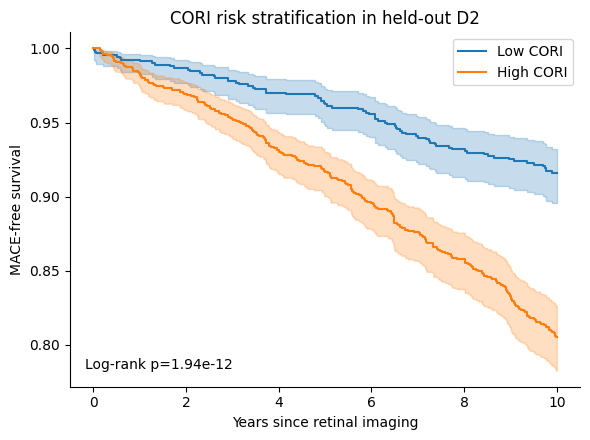

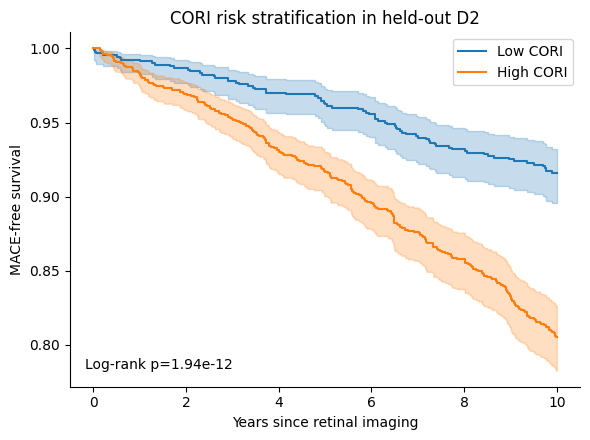

In [38]:
primary_performance = pd.DataFrame([
    performance_row(meanpool["D1"], "D1 development", "CORI_z", "CORI_high", BOOTSTRAPS),
    performance_row(meanpool["D2"], "D2 held-out", "CORI_z", "CORI_high", BOOTSTRAPS),
])
display(primary_performance)
save_table(primary_performance, "Table_02_primary_CORI_performance")

horizons = horizon_table(meanpool["D2"], "CORI_z", "CORI_high", horizons=(3, 5, 10))
save_table(horizons, "Table_03_CORI_horizon_performance")

km_plot(
    meanpool["D2"], "CORI_high", {0: "Low CORI", 1: "High CORI"},
    "CORI risk stratification in held-out D2", FIGURE_DIR / "Figure_02A_CORI_D2_KM",
)

## 9. Clinical, CORI, and combined models

F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_04_clinical_CORI_combined_performance.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_05_D2_multivariable_CORI_association.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_S_clinical_CORI_calibration_deciles.csv


,predicted,observed,N
0,0.041600,0.035556,225
1,0.062288,0.048889,225
2,0.082214,0.057778,225
3,0.104497,0.088889,225
4,0.129369,0.106667,225
5,0.155066,0.169643,224
6,0.182423,0.137778,225
7,0.213483,0.155556,225
8,0.260207,0.257778,225
9,0.376434,0.391111,225


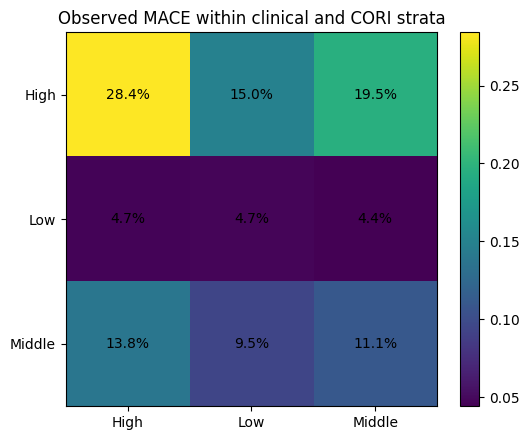

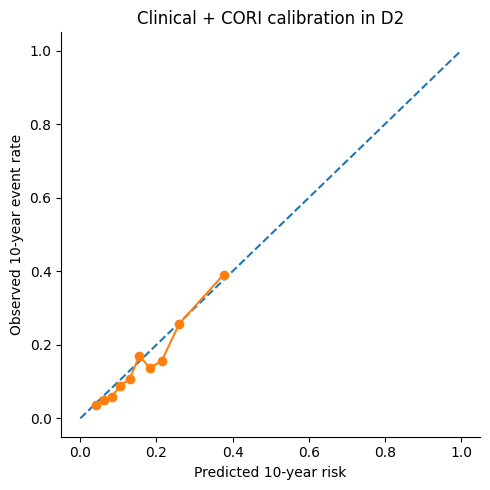

In [39]:
clinical_model = train_model(
    meanpool["D1"], CLINICAL_VARIABLES,
    name="Clinical", n_features=len(CLINICAL_VARIABLES), penalizer=0.01,
)
combined_features = [*CLINICAL_VARIABLES, "CORI_z"]
combined_model = train_model(
    meanpool["D1"], combined_features,
    name="Clinical_CORI", n_features=len(combined_features), penalizer=0.01,
)

for cohort in ["D1", "D2"]:
    meanpool[cohort] = score_model(clinical_model, meanpool[cohort])
    meanpool[cohort] = score_model(combined_model, meanpool[cohort])
    meanpool[cohort]["Clinical_risk_10y"] = predict_risk(clinical_model, meanpool[cohort], 10)
    meanpool[cohort]["Clinical_CORI_risk_10y"] = predict_risk(combined_model, meanpool[cohort], 10)

clinical_comparison = pd.DataFrame([
    {"model": "Clinical", "D1_C": c_index(meanpool["D1"], "Clinical_z"), "D2_C": c_index(meanpool["D2"], "Clinical_z")},
    {"model": "CORI", "D1_C": c_index(meanpool["D1"], "CORI_z"), "D2_C": c_index(meanpool["D2"], "CORI_z")},
    {"model": "Clinical + CORI", "D1_C": c_index(meanpool["D1"], "Clinical_CORI_z"), "D2_C": c_index(meanpool["D2"], "Clinical_CORI_z")},
])
save_table(clinical_comparison, "Table_04_clinical_CORI_combined_performance")

adjusted_cori, adjusted_cori_model = adjusted_cox(
    meanpool["D2"], "CORI_z", PRIMARY_ADJUSTMENT
)
save_table(adjusted_cori, "Table_05_D2_multivariable_CORI_association")

clinical_thresholds = score_thresholds(meanpool["D1"]["Clinical_risk_10y"])
for cohort in ["D1", "D2"]:
    meanpool[cohort] = add_groups(meanpool[cohort], "Clinical_risk_10y", clinical_thresholds, "Clinical_risk")

counts, event_rates, predicted = reclassification_tables(
    meanpool["D2"], "Clinical_risk_tertile", "CORI_tertile", value_column="Clinical_CORI_risk_10y"
)
counts.to_csv(TABLE_DIR / "Table_08A_clinical_to_CORI_counts.csv")
event_rates.to_csv(TABLE_DIR / "Table_08B_clinical_to_CORI_event_rates.csv")
predicted.to_csv(TABLE_DIR / "Table_08C_clinical_to_CORI_mean_predicted_risk.csv")
reclassification_heatmap(event_rates, "Observed MACE within clinical and CORI strata", FIGURE_DIR / "Figure_02B_clinical_CORI_reclassification")

calibration, _ = calibration_plot(
    meanpool["D2"], "Clinical_CORI_risk_10y", "Y_mace",
    "Clinical + CORI calibration in D2", FIGURE_DIR / "Figure_S_calibration_clinical_CORI",
)
save_table(calibration, "Table_S_clinical_CORI_calibration_deciles")

## 10. CORI versus controlled, tuned, practical, and matched MMACE

,cohort,model,C_index
0,D1,CORI locked,0.639694
1,D1,CORI tuned sensitivity,0.637839
2,D1,MMACE equal complexity,0.619659
3,D1,MMACE independently tuned,0.627364
4,D1,MMACE practical,0.627677
5,D1,MMACE matched ensemble sensitivity,0.619558
6,D2,CORI locked,0.639317
7,D2,CORI tuned sensitivity,0.639201
8,D2,MMACE equal complexity,0.634648
9,D2,MMACE independently tuned,0.654495


F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_09_cross_domain_CORI_MMACE.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_09C_paired_D2_delta_C.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_10C_MMACE_to_CORI_category_NRI.csv


,comparison,event_NRI,nonevent_NRI,total_NRI
0,Equal-complexity MMACE to CORI,-0.055215,0.099324,0.044109
1,Practical MMACE to CORI,-0.030675,0.041082,0.010407


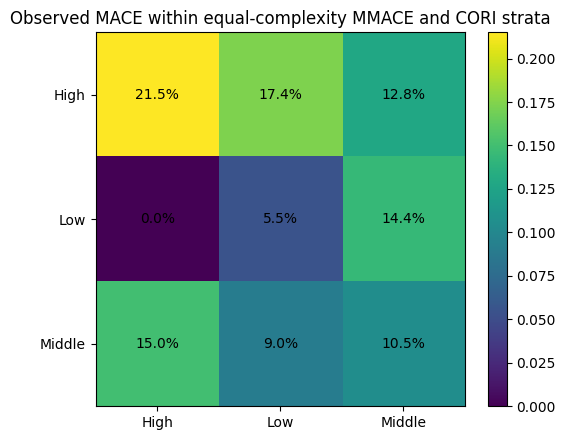

In [40]:
rows = []
score_models = [
    ("CORI locked", "CORI_z"),
    ("CORI tuned sensitivity", "CORI_tuned_z"),
    ("MMACE equal complexity", "MMACE_equal_z"),
    ("MMACE independently tuned", "MMACE_tuned_z"),
    ("MMACE practical", "MMACE_full_z"),
    ("MMACE matched ensemble sensitivity", "MMACE_matched_ensemble_z"),
]
for cohort in ["D1", "D2", "D3", "D4"]:
    for model_label, score_column in score_models:
        rows.append(
            {
                "cohort": cohort,
                "model": model_label,
                "C_index": c_index(meanpool[cohort], score_column),
            }
        )
for cohort in ["D2", "D4"]:
    rows.append(
        {
            "cohort": cohort,
            "model": "MMACE crude matched ensemble sensitivity",
            "C_index": c_index(
                meanpool[cohort],
                "MMACE_crude_matched_ensemble_z",
            ),
        }
    )

cross_domain = pd.DataFrame(rows)
display(cross_domain)
save_table(cross_domain, "Table_09_cross_domain_CORI_MMACE")

paired_rows = []
for label, score_column in [
    ("CORI minus equal-complexity MMACE", "MMACE_equal_z"),
    ("CORI minus independently tuned MMACE", "MMACE_tuned_z"),
    ("CORI minus practical MMACE", "MMACE_full_z"),
    ("CORI minus matched-MMACE ensemble sensitivity", "MMACE_matched_ensemble_z"),
]:
    paired_rows.append(
        {
            "comparison": label,
            **paired_delta_c(
                meanpool["D2"],
                "CORI_z",
                score_column,
                BOOTSTRAPS,
                SEED,
            ),
        }
    )
save_table(pd.DataFrame(paired_rows), "Table_09C_paired_D2_delta_C")

# Primary participant-level reclassification uses deterministic equal-complexity MMACE.
counts, event_rates, _ = reclassification_tables(
    meanpool["D2"],
    "MMACE_equal_tertile",
    "CORI_tertile",
)
counts.to_csv(TABLE_DIR / "Table_10A_equal_MMACE_to_CORI_counts.csv")
event_rates.to_csv(TABLE_DIR / "Table_10B_equal_MMACE_to_CORI_event_rates.csv")
reclassification_heatmap(
    event_rates,
    "Observed MACE within equal-complexity MMACE and CORI strata",
    FIGURE_DIR / "Figure_03A_equal_MMACE_CORI_reclassification",
)

nri_rows = [
    {
        "comparison": "Equal-complexity MMACE to CORI",
        **categorical_nri(
            meanpool["D2"],
            "MMACE_equal_tertile",
            "CORI_tertile",
        ),
    },
    {
        "comparison": "Practical MMACE to CORI",
        **categorical_nri(
            meanpool["D2"],
            "MMACE_full_tertile",
            "CORI_tertile",
        ),
    },
]
save_table(pd.DataFrame(nri_rows), "Table_10C_MMACE_to_CORI_category_NRI")

## 11. Development-fitted residualization and direct incremental value

In [41]:
residual_performance_rows = []
incremental_rows = []
residual_parameter_rows = []

comparators = [
    ("equal", "Equal-complexity MMACE", "MMACE_equal_z"),
    ("tuned", "Independently tuned MMACE", "MMACE_tuned_z"),
    ("practical", "Practical MMACE", "MMACE_full_z"),
]

for key, label, reference_score in comparators:
    output_column = f"CORI_residual_{key}"

    d1_residualized, parameters = residualize(
        meanpool["D1"],
        meanpool["D1"],
        target="CORI_z",
        reference=reference_score,
        output=output_column,
    )
    d2_residualized, _ = residualize(
        meanpool["D1"],
        meanpool["D2"],
        target="CORI_z",
        reference=reference_score,
        output=output_column,
    )

    meanpool["D1"][output_column] = d1_residualized[output_column]
    meanpool["D2"][output_column] = d2_residualized[output_column]

    thresholds = score_thresholds(meanpool["D1"][output_column])
    meanpool["D2"] = add_groups(
        meanpool["D2"],
        output_column,
        thresholds,
        output_column,
    )

    residual_parameter_rows.append(
        {"comparator": label, **parameters}
    )
    residual_performance_rows.append(
        {
            "comparator": label,
            **performance_row(
                meanpool["D2"],
                f"CORI residualized on {label}",
                output_column,
                f"{output_column}_high",
                BOOTSTRAPS,
            ),
        }
    )

    # Direct conditional test is primary.
    incremental_rows.append(
        {
            "comparison": f"CORI beyond {label}",
            **stratified_incremental_test(
                meanpool["D2"],
                base_score=reference_score,
                added_score="CORI_z",
                covariates=PRIMARY_ADJUSTMENT,
            ),
        }
    )
    # Linear residual and raw CORI span the same nested model; this row
    # verifies that the residualized parameterization gives the same inference.
    incremental_rows.append(
        {
            "comparison": f"Residualized CORI beyond {label}",
            **stratified_incremental_test(
                meanpool["D2"],
                base_score=reference_score,
                added_score=output_column,
                covariates=PRIMARY_ADJUSTMENT,
            ),
        }
    )

residual_performance = pd.DataFrame(residual_performance_rows)
incremental_results = pd.DataFrame(incremental_rows)
display(residual_performance)
display(incremental_results)

save_table(
    pd.DataFrame(residual_parameter_rows),
    "Table_S_residualization_parameters",
)
save_table(
    residual_performance,
    "Table_01B_CORI_residualized_MMACE",
)
save_table(
    incremental_results,
    "Table_10D_incremental_CORI_symmetric_comparators",
)

,comparator,cohort,N,events,C_index,C_low,C_high,successful_bootstraps,HR,HR_low,HR_high,p
0,Equal-complexity MMACE,CORI residualized on Equal-complexity MMACE,2249,326,0.549168,0.517489,0.582538,1000,1.336445,1.062291,1.681351,0.013292
1,Independently tuned MMACE,CORI residualized on Independently tuned MMACE,2249,326,0.519563,0.490325,0.549975,1000,1.124203,0.895333,1.411579,0.313441
2,Practical MMACE,CORI residualized on Practical MMACE,2249,326,0.524080,0.493505,0.555263,1000,1.271500,1.007325,1.604957,0.043240


,comparison,base_score,added_score,N,events,added_HR,added_HR_low,added_HR_high,added_p,LR_chi2,LR_p,C_reduced,C_full,delta_C
0,CORI beyond Equal-complexity MMACE,MMACE_equal_z,CORI_z,2249,326,1.288894,1.007463,1.648941,0.043474,4.275214,0.038672,0.706503,0.707701,0.001199
1,Residualized CORI beyond Equal-complexity MMACE,MMACE_equal_z,CORI_residual_equal,2249,326,1.288894,1.007463,1.648941,0.043474,4.275214,0.038672,0.706503,0.707701,0.001199
2,CORI beyond Independently tuned MMACE,MMACE_tuned_z,CORI_z,2249,326,1.140146,0.923606,1.407453,0.222289,1.569878,0.210225,0.707395,0.708100,0.000705
3,Residualized CORI beyond Independently tuned MMACE,MMACE_tuned_z,CORI_residual_tuned,2249,326,1.140146,0.923606,1.407453,0.222289,1.569878,0.210225,0.707395,0.708100,0.000705
4,CORI beyond Practical MMACE,MMACE_full_z,CORI_z,2249,326,1.139281,0.930634,1.394707,0.206435,1.691330,0.193426,0.707844,0.708285,0.000441
5,Residualized CORI beyond Practical MMACE,MMACE_full_z,CORI_residual_practical,2249,326,1.139281,0.930634,1.394707,0.206435,1.691330,0.193426,0.707844,0.708285,0.000441


F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_S_residualization_parameters.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_01B_CORI_residualized_MMACE.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_10D_incremental_CORI_symmetric_comparators.csv


,comparison,base_score,added_score,N,events,added_HR,added_HR_low,added_HR_high,added_p,LR_chi2,LR_p,C_reduced,C_full,delta_C
0,CORI beyond Equal-complexity MMACE,MMACE_equal_z,CORI_z,2249,326,1.288894,1.007463,1.648941,0.043474,4.275214,0.038672,0.706503,0.707701,0.001199
1,Residualized CORI beyond Equal-complexity MMACE,MMACE_equal_z,CORI_residual_equal,2249,326,1.288894,1.007463,1.648941,0.043474,4.275214,0.038672,0.706503,0.707701,0.001199
2,CORI beyond Independently tuned MMACE,MMACE_tuned_z,CORI_z,2249,326,1.140146,0.923606,1.407453,0.222289,1.569878,0.210225,0.707395,0.708100,0.000705
3,Residualized CORI beyond Independently tuned MMACE,MMACE_tuned_z,CORI_residual_tuned,2249,326,1.140146,0.923606,1.407453,0.222289,1.569878,0.210225,0.707395,0.708100,0.000705
4,CORI beyond Practical MMACE,MMACE_full_z,CORI_z,2249,326,1.139281,0.930634,1.394707,0.206435,1.691330,0.193426,0.707844,0.708285,0.000441
5,Residualized CORI beyond Practical MMACE,MMACE_full_z,CORI_residual_practical,2249,326,1.139281,0.930634,1.394707,0.206435,1.691330,0.193426,0.707844,0.708285,0.000441


## 12. Event-matched learning-curve summary

F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_09B_matched_MMACE_290_event_draws.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_09B_event_matched_learning_curve.csv


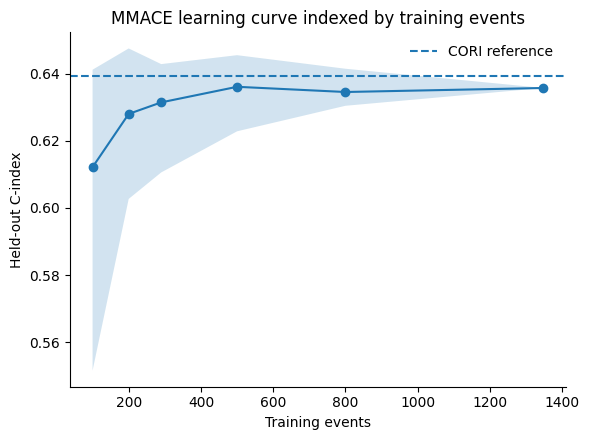

In [42]:
learning_summary = matched_draws[
    ["repetition", "train_N", "train_events", "C_D2", "C_D4"]
].copy()
save_table(learning_summary, "Table_09B_matched_MMACE_290_event_draws")

if RUN_FULL_LEARNING_CURVE:
    event_repetitions = {
        100: 80,
        200: 80,
        290: 80,
        500: 40,
        800: 30,
        1348: 1,
    }
    full_learning_curve = information_matched_learning_curve(
        source_development=meanpool["D3"],
        target_development=meanpool["D1"],
        evaluation=meanpool["D2"],
        feature_columns=DEEP_FEATURES,
        n_features=CORI_K,
        penalizer=CORI_PENALIZER,
        match_columns=MATCH_VARIABLES,
        event_repetitions=event_repetitions,
        seed=SEED,
    )
    save_table(
        full_learning_curve,
        "Table_09B_event_matched_learning_curve",
    )
    learning_curve_plot(
        full_learning_curve,
        "train_events",
        "C_D2",
        c_index(meanpool["D2"], "CORI_z"),
        "MMACE learning curve indexed by training events",
        FIGURE_DIR / "Figure_S_event_matched_learning_curve",
    )

In [ ]:
# scatter plot for pred prob CORI vs MMACE, eith corr vaules


In [ ]:
#

In [43]:
# Primary equal-information result: individual matched-model distribution.
cori_D2 = c_index(meanpool["D2"], "CORI_z")
cori_D4 = c_index(meanpool["D4"], "CORI_z")

summary = pd.DataFrame(
    [
        {
            "comparator": "Covariate/event-matched MMACE individual models",
            "cohort": "D2",
            **matched_curve_summary(matched_draws, "C_D2", cori_D2),
        },
        {
            "comparator": "Covariate/event-matched MMACE individual models",
            "cohort": "D4",
            **matched_curve_summary(matched_draws, "C_D4", cori_D4),
        },
        {
            "comparator": "Crude event-matched MMACE individual models",
            "cohort": "D2",
            **matched_curve_summary(crude_matched_draws, "C_D2", cori_D2),
        },
        {
            "comparator": "Crude event-matched MMACE individual models",
            "cohort": "D4",
            **matched_curve_summary(crude_matched_draws, "C_D4", cori_D4),
        },
        {
            "comparator": "Equal-complexity full-D3 MMACE",
            "cohort": "D2",
            "reps": 1,
            "median_C": round(c_index(meanpool["D2"], "MMACE_equal_z"), 4),
            "C_low": None,
            "C_high": None,
            "P_greater_than_CORI": None,
        },
        {
            "comparator": "Independently tuned MMACE",
            "cohort": "D2",
            "reps": 1,
            "median_C": round(c_index(meanpool["D2"], "MMACE_tuned_z"), 4),
            "C_low": None,
            "C_high": None,
            "P_greater_than_CORI": None,
        },
        {
            "comparator": "Practical MMACE",
            "cohort": "D2",
            "reps": 1,
            "median_C": round(c_index(meanpool["D2"], "MMACE_full_z"), 4),
            "C_low": None,
            "C_high": None,
            "P_greater_than_CORI": None,
        },
        {
            "comparator": "Matched-MMACE averaged ensemble sensitivity",
            "cohort": "D2",
            "reps": MATCHED_REPETITIONS,
            "median_C": round(
                c_index(meanpool["D2"], "MMACE_matched_ensemble_z"),
                4,
            ),
            "C_low": None,
            "C_high": None,
            "P_greater_than_CORI": None,
        },
    ]
)
save_table(summary, "Table_09B_matched_MMACE_summary")
display(summary)

F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_09B_matched_MMACE_summary.csv


,comparator,cohort,reps,median_C,C_low,C_high,P_greater_than_CORI
0,Covariate/event-matched MMACE individual models,D2,200,0.6321,0.6059,0.6466,0.15
1,Covariate/event-matched MMACE individual models,D4,200,0.6107,0.5870,0.6205,0.37
2,Crude event-matched MMACE individual models,D2,200,0.6317,0.6081,0.6452,0.15
3,Crude event-matched MMACE individual models,D4,200,0.6133,0.5965,0.6225,0.51
4,Equal-complexity full-D3 MMACE,D2,1,0.6346,NaN,NaN,NaN
5,Independently tuned MMACE,D2,1,0.6545,NaN,NaN,NaN
6,Practical MMACE,D2,1,0.6568,NaN,NaN,NaN
7,Matched-MMACE averaged ensemble sensitivity,D2,200,0.6475,NaN,NaN,NaN


## 13. Treatment-stratified and treatment-adjusted analyses

In [44]:
treatment_rows = []
for value, label in [(0, "No recorded systemic treatment"), (1, "Any recorded systemic treatment")]:
    subset = meanpool["D2"].loc[meanpool["D2"]["any_treatment"] == value]
    if subset["Y_mace"].sum() >= 5:
        treatment_rows.append(performance_row(subset, label, "CORI_z", "CORI_high", 500))
treatment_performance = pd.DataFrame(treatment_rows)
save_table(treatment_performance, "Table_11A_treatment_stratified_CORI")

adjusted_treatment, _ = adjusted_cox(
    meanpool["D2"], "CORI_z", [*TREATMENT_COLUMNS, *PRIMARY_ADJUSTMENT]
)
save_table(adjusted_treatment, "Table_11B_treatment_adjusted_CORI")

interaction_rows = []
for treatment_column in [*TREATMENT_COLUMNS, "any_treatment"]:
    summary, _ = adjusted_cox(
        meanpool["D2"], "CORI_z", PRIMARY_ADJUSTMENT,
        interaction_column=treatment_column,
    )
    interaction_term = f"CORI_z_x_{treatment_column}"
    row = summary.loc[summary["term"] == interaction_term].iloc[0].to_dict()
    row["treatment"] = treatment_column
    interaction_rows.append(row)
save_table(pd.DataFrame(interaction_rows), "Table_11C_treatment_by_CORI_interactions")

F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_11A_treatment_stratified_CORI.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_11B_treatment_adjusted_CORI.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_11C_treatment_by_CORI_interactions.csv


,term,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p),HR,HR_low,HR_high,N,events,adjusted_for,dropped_constant,treatment
0,CORI_z_x_has_target_drug,-0.131904,0.876425,0.238375,-0.599110,0.335302,0.549300,1.398363,0.0,-0.553347,0.580026,0.785811,0.876425,0.549300,1.398363,2249,326,"age, female, Diabetes, HTN, has_target_drug",,has_target_drug
1,CORI_z_x_has_chemo,-0.085960,0.917631,0.488854,-1.044095,0.872175,0.352010,2.392109,0.0,-0.175840,0.860420,0.216888,0.917631,0.352010,2.392109,2249,326,"age, female, Diabetes, HTN, has_chemo",,has_chemo
2,CORI_z_x_has_io,-0.165919,0.847114,0.264811,-0.684939,0.353100,0.504121,1.423474,0.0,-0.626558,0.530949,0.913355,0.847114,0.504121,1.423474,2249,326,"age, female, Diabetes, HTN, has_io",,has_io
3,CORI_z_x_any_treatment,-0.131904,0.876425,0.238375,-0.599110,0.335302,0.549300,1.398363,0.0,-0.553347,0.580026,0.785811,0.876425,0.549300,1.398363,2249,326,"age, female, Diabetes, HTN, any_treatment",,any_treatment


## 14. Center-level performance

F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_07_center_level_CORI_performance.csv


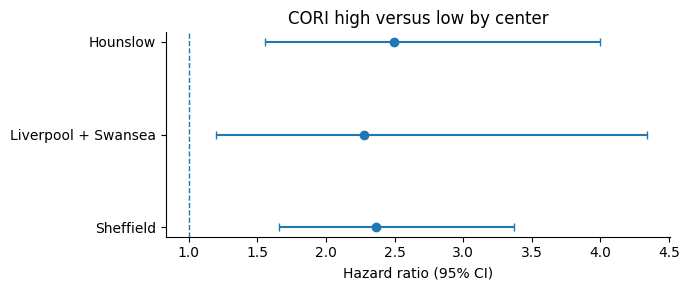

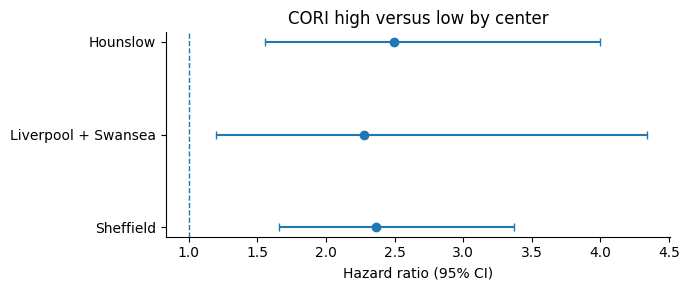

In [45]:
center_data = meanpool["D2"].copy()
center_data["reporting_center"] = center_data["center"].replace({"Liverpool": "Liverpool + Swansea", "Swansea": "Liverpool + Swansea"})
center_rows = []
for center, subset in center_data.groupby("reporting_center"):
    if subset["Y_mace"].sum() >= 5:
        center_rows.append(performance_row(subset, center, "CORI_z", "CORI_high", 500))
center_table = pd.DataFrame(center_rows)
save_table(center_table, "Table_07_center_level_CORI_performance")
forest_plot(center_table, "cohort", "HR", "HR_low", "HR_high", "CORI high versus low by center", FIGURE_DIR / "Figure_S_center_forest")

## 15. Age, sex, treatment, and cancer-site subgroup analyses

,subgroup,level,N,events,HR,HR_low,HR_high,p,adjusted_for,dropped_constant,forest_label
0,age_group,Age <60,1111,85,1.130428,0.872334,1.464884,0.353875,"age, female, Diabetes, HTN",,Age: Age <60
1,age_group,Age ≥60,1138,241,1.258167,1.083908,1.460441,0.002534,"age, female, Diabetes, HTN",,Age: Age ≥60
2,cancer_site,BreastCancer,344,45,1.587654,1.116638,2.257353,0.010043,NaN,,Cancer site: BreastCancer
3,cancer_site,DigestiveCancer,146,35,1.266627,0.833103,1.925744,0.268843,NaN,,Cancer site: DigestiveCancer
4,cancer_site,HeamatoCancer,104,26,1.037086,0.670782,1.603423,0.869890,NaN,,Cancer site: HeamatoCancer
5,cancer_site,InsituCancer,157,21,1.407642,0.917969,2.158523,0.116985,NaN,,Cancer site: InsituCancer
6,cancer_site,MaleRepoCancer,156,39,1.345537,0.927915,1.951117,0.117497,NaN,female,Cancer site: MaleRepoCancer
7,cancer_site,SecondaryCancer,256,50,1.397285,0.986712,1.978699,0.059483,NaN,,Cancer site: SecondaryCancer
8,cancer_site,SkinCancer,357,69,1.318936,0.993764,1.750507,0.055282,NaN,,Cancer site: SkinCancer
9,sex_group,Female,1506,167,1.150636,0.969985,1.364931,0.107346,"age, Diabetes, HTN",female,Sex: Female


F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_12_subgroup_CORI_associations.csv


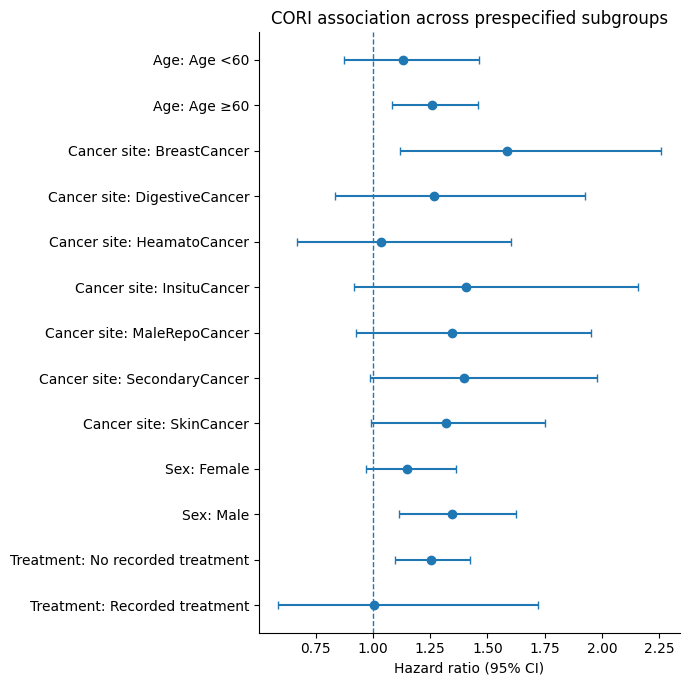

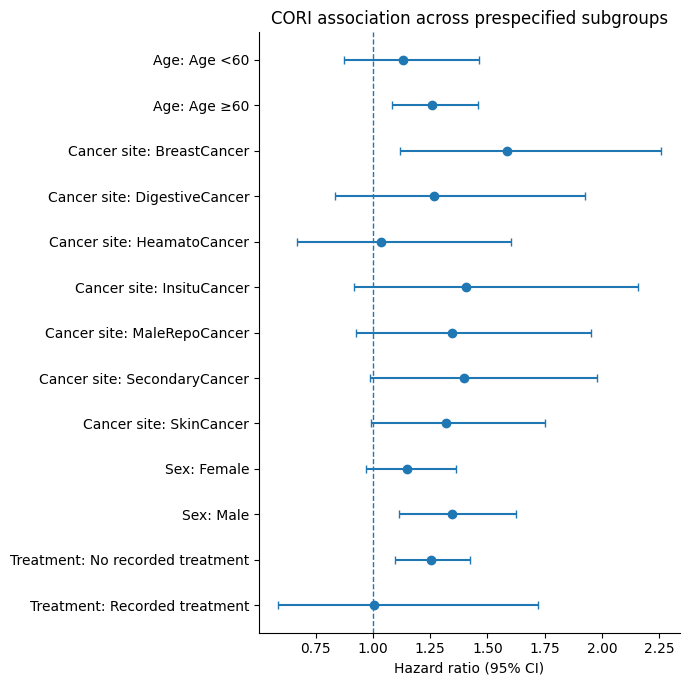

In [46]:
# ============================================================
# Prespecified CORI subgroup associations in held-out D2
# ============================================================

d2_subgroups = meanpool["D2"].copy()

d2_subgroups["age_group"] = np.where(
    d2_subgroups["age"] < 60,
    "Age <60",
    "Age ≥60",
)

d2_subgroups["sex_group"] = np.where(
    d2_subgroups["female"] == 1,
    "Female",
    "Male",
)

d2_subgroups["treatment_group"] = np.where(
    d2_subgroups["any_treatment"] == 1,
    "Recorded treatment",
    "No recorded treatment",
)


# ------------------------------------------------------------
# Age, sex, and recorded-treatment subgroups
# ------------------------------------------------------------

subgroup_tables = [
    subgroup_cox(
        d2_subgroups,
        score_column="CORI_z",
        subgroup_column="age_group",
        minimum_events=20,
        covariates=PRIMARY_ADJUSTMENT,
    ),
    subgroup_cox(
        d2_subgroups,
        score_column="CORI_z",
        subgroup_column="sex_group",
        minimum_events=20,
        covariates=PRIMARY_ADJUSTMENT,
    ),
    subgroup_cox(
        d2_subgroups,
        score_column="CORI_z",
        subgroup_column="treatment_group",
        minimum_events=15,
        covariates=PRIMARY_ADJUSTMENT,
    ),
]


# ------------------------------------------------------------
# Cancer-site subgroups
# ------------------------------------------------------------

for site in CANCER_SITE_COLUMNS:
    if site not in d2_subgroups.columns:
        continue

    site_data = d2_subgroups.loc[
        d2_subgroups[site]
        .fillna(0)
        .astype(int)
        .eq(1)
    ].copy()

    events = int(site_data["Y_mace"].sum())

    if events < 20:
        continue

    summary, _ = adjusted_cox(
        site_data,
        score_column="CORI_z",
        covariates=PRIMARY_ADJUSTMENT,
        penalizer=0.01,
    )

    score_row = summary.loc[
        summary["term"] == "CORI_z"
    ].iloc[0]

    subgroup_tables.append(
        pd.DataFrame(
            [
                {
                    "subgroup": "cancer_site",
                    "level": site.replace(
                        "_present",
                        "",
                    ),
                    "N": int(score_row["N"]),
                    "events": int(
                        score_row["events"]
                    ),
                    "HR": score_row["HR"],
                    "HR_low": score_row["HR_low"],
                    "HR_high": score_row["HR_high"],
                    "p": score_row["p"],
                    "dropped_constant": (
                        score_row[
                            "dropped_constant"
                        ]
                    ),
                }
            ]
        )
    )


# ------------------------------------------------------------
# Combine and save
# ------------------------------------------------------------

subgroup_tables = [
    table
    for table in subgroup_tables
    if table is not None
    and not table.empty
]

subgroups = pd.concat(
    subgroup_tables,
    ignore_index=True,
)

subgroup_labels = {
    "age_group": "Age",
    "sex_group": "Sex",
    "treatment_group": "Treatment",
    "cancer_site": "Cancer site",
}

subgroups["forest_label"] = (
    subgroups["subgroup"]
    .map(subgroup_labels)
    .fillna(subgroups["subgroup"])
    + ": "
    + subgroups["level"].astype(str)
)

subgroups = (
    subgroups
    .sort_values(
        ["subgroup", "level"]
    )
    .reset_index(drop=True)
)

display(subgroups)

save_table(
    subgroups,
    "Table_12_subgroup_CORI_associations",
)


# ------------------------------------------------------------
# Forest plot
# The keyword names must match src/plots.py exactly.
# ------------------------------------------------------------

forest_plot(
    df=subgroups,
    label="forest_label",
    estimate="HR",
    lower="HR_low",
    upper="HR_high",
    title=(
        "CORI association across "
        "prespecified subgroups"
    ),
    path=(
        FIGURE_DIR
        / "Figure_S_subgroup_forest"
    ),
)

## 16. Cancer-specific interaction structure across representations

This section answers the specificity question. It does not use score superiority or event matching as evidence of cancer specificity.

In [47]:
representation_summaries = []
if RUN_ALL_REPRESENTATIONS:
    for representation in REPRESENTATION_DIRS:
        rep = {
            cohort: load_cohort(cohort_path(cohort, representation), DEEP_FEATURES)
            for cohort in ["D1", "D2", "D3", "D4"]
        }
        feature_table, summary = interaction_replication(
            rep["D1"], rep["D3"], rep["D2"], rep["D4"], DEEP_FEATURES
        )
        summary["representation"] = representation
        summary["permutation_p"] = permuted_replication_p(feature_table, repetitions=1000, seed=SEED)
        representation_summaries.append(summary)
        save_table(feature_table, f"specificity_{representation}_feature_interactions")

representation_table = pd.DataFrame(representation_summaries)
save_table(representation_table, "Table_13_representation_specificity")

F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\specificity_meanpool_pre_feature_interactions.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\specificity_meanpool_norm_feature_interactions.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\specificity_cls_feature_interactions.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\specificity_maxpool_feature_interactions.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\specificity_blk18_feature_interactions.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\specificity_topk10_feature_interactions.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\specificity_stdpool_feature_interactions.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_13_representation_specificity.csv


,n_features,development_nominal_p_lt_0_05,development_global_fisher_p,heldout_replication_r,heldout_replication_p,representation,permutation_p
0,1024,46,4.276510e-03,-0.213940,4.581564e-12,meanpool_pre,1.000000
1,1016,46,2.863024e-02,-0.215763,3.628316e-12,meanpool_norm,1.000000
2,1016,149,9.073342e-35,0.198751,1.645710e-10,cls,0.000999
3,1016,68,1.187216e-02,-0.095998,2.189747e-03,maxpool,0.998002
4,1024,39,8.090511e-06,-0.189999,8.874380e-10,blk18,1.000000
5,1016,64,8.865179e-06,-0.131071,2.779602e-05,topk10,1.000000
6,1015,98,1.897250e-16,-0.092396,3.215618e-03,stdpool,0.999001


## 17. Score-level cancer-status interactions and direct CORI-versus-MMACE contrasts

In [48]:
interaction_specs = [
    ("CORI locked", "CORI_z"),
    ("CORI tuned sensitivity", "CORI_tuned_z"),
    ("MMACE equal complexity", "MMACE_equal_z"),
    ("MMACE independently tuned", "MMACE_tuned_z"),
    ("MMACE practical", "MMACE_full_z"),
    ("MMACE matched ensemble sensitivity", "MMACE_matched_ensemble_z"),
]

score_interactions = pd.DataFrame(
    [
        {
            "score": label,
            **score_interaction_test(
                meanpool["D2"],
                meanpool["D4"],
                score_column,
                PRIMARY_ADJUSTMENT,
            ),
        }
        for label, score_column in interaction_specs
    ]
)
display(score_interactions)
save_table(
    score_interactions,
    "Table_13B_score_level_cancer_interactions",
)

direct_interaction_contrasts = pd.DataFrame(
    [
        {
            "comparison": "CORI versus equal-complexity MMACE",
            **dual_score_interaction_test(
                meanpool["D2"],
                meanpool["D4"],
                "CORI_z",
                "MMACE_equal_z",
                PRIMARY_ADJUSTMENT,
            ),
        },
        {
            "comparison": "CORI versus independently tuned MMACE",
            **dual_score_interaction_test(
                meanpool["D2"],
                meanpool["D4"],
                "CORI_z",
                "MMACE_tuned_z",
                PRIMARY_ADJUSTMENT,
            ),
        },
        {
            "comparison": "CORI versus practical MMACE",
            **dual_score_interaction_test(
                meanpool["D2"],
                meanpool["D4"],
                "CORI_z",
                "MMACE_full_z",
                PRIMARY_ADJUSTMENT,
            ),
        },
    ]
)
display(direct_interaction_contrasts)
save_table(
    direct_interaction_contrasts,
    "Table_13C_direct_CORI_vs_MMACE_interaction_contrast",
)

,score,never_cancer_HR,cancer_HR,cancer_HR_low,cancer_HR_high,interaction_HR,interaction_HR_low,interaction_HR_high,interaction_p,N,events
0,CORI locked,1.045898,1.231515,1.089873,1.391566,1.177471,1.031260,1.344411,0.015735,17012,1787
1,CORI tuned sensitivity,1.047695,1.227746,1.087625,1.385919,1.171855,1.028107,1.335700,0.017544,17012,1787
2,MMACE equal complexity,1.049031,1.173703,1.040042,1.324541,1.118844,0.980115,1.277210,0.096395,17012,1787
3,MMACE independently tuned,1.053297,1.224476,1.080798,1.387253,1.162516,1.013776,1.333080,0.031096,17012,1787
4,MMACE practical,1.052186,1.230327,1.082092,1.398868,1.169305,1.016451,1.345146,0.028651,17012,1787
5,MMACE matched ensemble sensitivity,1.050321,1.251798,1.088868,1.439107,1.191824,1.021751,1.390206,0.025491,17012,1787


F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_13B_score_level_cancer_interactions.csv


,comparison,MMACE_comparator,CORI_interaction_HR,CORI_interaction_p,MMACE_interaction_HR,MMACE_interaction_p,interaction_ratio_CORI_vs_MMACE,difference_z,difference_p,N,events
0,CORI versus equal-complexity MMACE,MMACE_equal_z,1.299079,0.054122,0.894235,0.405659,1.452726,1.462915,0.143491,17012,1787
1,CORI versus independently tuned MMACE,MMACE_tuned_z,1.126962,0.298208,1.053910,0.655796,1.069315,0.310223,0.756391,17012,1787
2,CORI versus practical MMACE,MMACE_full_z,1.121045,0.300848,1.064624,0.588743,1.052996,0.247719,0.804352,17012,1787


F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_13C_direct_CORI_vs_MMACE_interaction_contrast.csv


,comparison,MMACE_comparator,CORI_interaction_HR,CORI_interaction_p,MMACE_interaction_HR,MMACE_interaction_p,interaction_ratio_CORI_vs_MMACE,difference_z,difference_p,N,events
0,CORI versus equal-complexity MMACE,MMACE_equal_z,1.299079,0.054122,0.894235,0.405659,1.452726,1.462915,0.143491,17012,1787
1,CORI versus independently tuned MMACE,MMACE_tuned_z,1.126962,0.298208,1.053910,0.655796,1.069315,0.310223,0.756391,17012,1787
2,CORI versus practical MMACE,MMACE_full_z,1.121045,0.300848,1.064624,0.588743,1.052996,0.247719,0.804352,17012,1787


## 18. Handcrafted comparator

The same generic `train_model` function is used. No special handcrafted model class is needed.

Loaded 54,060 participants and 453 HC features.


,cohort,original_N,original_events,handcrafted_N,handcrafted_events,matched_percent,missing_handcrafted_N,missing_handcrafted_events
0,D1,2009,290,2008,290,99.950224,1,0
1,D2,2249,326,2249,326,100.000000,0,0
2,D3,14159,1348,14149,1348,99.929374,10,0
3,D4,14763,1461,14755,1461,99.945810,8,0


F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_14A_handcrafted_feature_coverage.csv
Using 453 nonconstant HC features.


,cohort,model,representation,N,events,C_index
0,D1,HCORI,Handcrafted,2008,290,0.586822
1,D1,HMMACE,Handcrafted,2008,290,0.568171
2,D1,CORI,Meanpool,2008,290,0.639710
3,D1,MMACE equal complexity,Meanpool,2008,290,0.619710
4,D1,MMACE practical,Meanpool,2008,290,0.627707
5,D2,HCORI,Handcrafted,2249,326,0.557094
6,D2,HMMACE,Handcrafted,2249,326,0.590212
7,D2,CORI,Meanpool,2249,326,0.639317
8,D2,MMACE equal complexity,Meanpool,2249,326,0.634648
9,D2,MMACE practical,Meanpool,2249,326,0.656800


F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_14B_handcrafted_cross_domain.csv


f:\CORI_Final\CORI_JACC_Final\CORI_Submit\code\src\plots.py:146: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


,feature,heldout_N,heldout_raw_rho,heldout_raw_p,heldout_raw_q,heldout_raw_pearson_r,heldout_raw_pearson_p,heldout_raw_pearson_q,heldout_partial_rho,heldout_p,heldout_q
0,HC_vessel_All_pixel_degree_3,2249,-0.391385,3.194028e-83,1.446894e-80,-0.375394,3.441254e-76,7.794440e-74,-0.201675,4.535255e-22,2.568088e-20
1,HC_vessel_All_STD_branch_distance,2249,0.380977,1.337582e-78,3.029623e-76,0.354118,1.989249e-67,1.126412e-65,0.222331,1.380522e-26,2.084588e-24
2,HC_vein_All_pixel_degree_3,2249,-0.376700,9.486318e-77,1.432434e-74,-0.376368,1.317693e-76,5.969149e-74,-0.165622,2.686146e-15,3.380067e-14
3,HC_vessel_All_STD_branch_length,2249,0.373645,1.914998e-75,2.168735e-73,0.348715,2.625639e-65,1.189415e-63,0.215031,6.170007e-25,6.987533e-23
4,HC_vessel_fundus_ring_75_125total_connected_pixels,2249,-0.369629,9.477346e-74,8.586476e-72,-0.350035,8.040304e-66,4.046953e-64,-0.204658,1.080176e-22,8.155329e-21
5,HC_vein_All_total_connected_pixels,2249,-0.369037,1.677111e-73,1.266219e-71,-0.362828,6.197294e-71,9.357914e-69,-0.148826,1.307774e-12,1.057896e-11
6,HC_vein_Allr_VD_binary,2249,-0.368667,2.393534e-73,1.548959e-71,-0.005567,7.918730e-01,9.081480e-01,-0.148382,1.526229e-12,1.192038e-11
7,HC_vein_Allr_FD_binary,2249,-0.368066,4.266613e-73,2.415970e-71,-0.017033,4.194587e-01,5.828674e-01,-0.146225,3.211322e-12,2.424548e-11
8,HC_vessel_fundus_ring_75_125pixel_degree_2,2249,-0.367774,5.641183e-73,2.839396e-71,-0.346697,1.588328e-64,5.995940e-63,-0.203531,1.862787e-22,1.205489e-20
9,HC_vessel_fundus_ring_125_175total_connected_pixels,2249,-0.367269,9.154668e-73,4.147064e-71,-0.344831,8.286502e-64,2.887527e-62,-0.198166,2.383606e-21,9.816123e-20


,feature,development_N,development_partial_rho,development_p,heldout_N,heldout_partial_rho,heldout_p,heldout_raw_rho,heldout_raw_p,heldout_q,same_direction
0,HC_vessel_Allr_Average_width,2008,0.167881,3.675649e-14,2249,0.005605,7.904841e-01,-0.038430,6.843160e-02,8.885590e-01,True
1,HC_artery_disc_ring_74_111total_connected_pixels,2008,-0.150146,1.358061e-11,2249,-0.152640,3.403156e-13,-0.254045,1.844899e-34,3.022803e-12,True
2,HC_artery_disc_ring_74_111pixel_degree_2,2008,-0.149210,1.820916e-11,2249,-0.150649,6.902210e-13,-0.250825,1.313415e-33,5.899436e-12,True
3,HC_artery_fundus_ring_75_125pixel_degree_2,2008,-0.146031,4.866808e-11,2249,-0.238050,2.409989e-30,-0.364361,1.457257e-71,5.458625e-28,True
4,HC_artery_fundus_ring_75_125total_connected_pixels,2008,-0.142988,1.222733e-10,2249,-0.238172,2.248204e-30,-0.365183,6.683145e-72,5.458625e-28,True
5,HC_artery_disc_ring_111_185pixel_degree_2,2008,-0.142005,1.639484e-10,2249,-0.172309,1.893943e-16,-0.292050,1.814262e-45,2.859854e-15,True
6,HC_artery_disc_ring_111_185total_connected_pixels,2008,-0.140665,2.437931e-10,2249,-0.174461,7.885275e-17,-0.294595,2.871248e-46,1.231734e-15,True
7,HC_artery_fundus_ring_125_175pixel_degree_3,2008,-0.124845,1.989956e-08,2249,-0.178294,1.609751e-17,-0.294173,3.901574e-46,2.916868e-16,True
8,HC_artery_disc_ring_74_111pixel_degree_1,2008,-0.117314,1.350402e-07,2249,-0.140772,2.005758e-11,-0.230045,2.142546e-28,1.397859e-10,True
9,HC_artery_disc_ring_111_185pixel_degree_3,2008,-0.116986,1.464188e-07,2249,-0.158432,4.123418e-14,-0.251793,7.302383e-34,4.343973e-13,True


F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_14C_all_handcrafted_CORI_correlations.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_14D_D1_selected_D2_replicated_handcrafted_correlations.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_14E_top10_raw_D2_handcrafted_CORI_correlations.csv


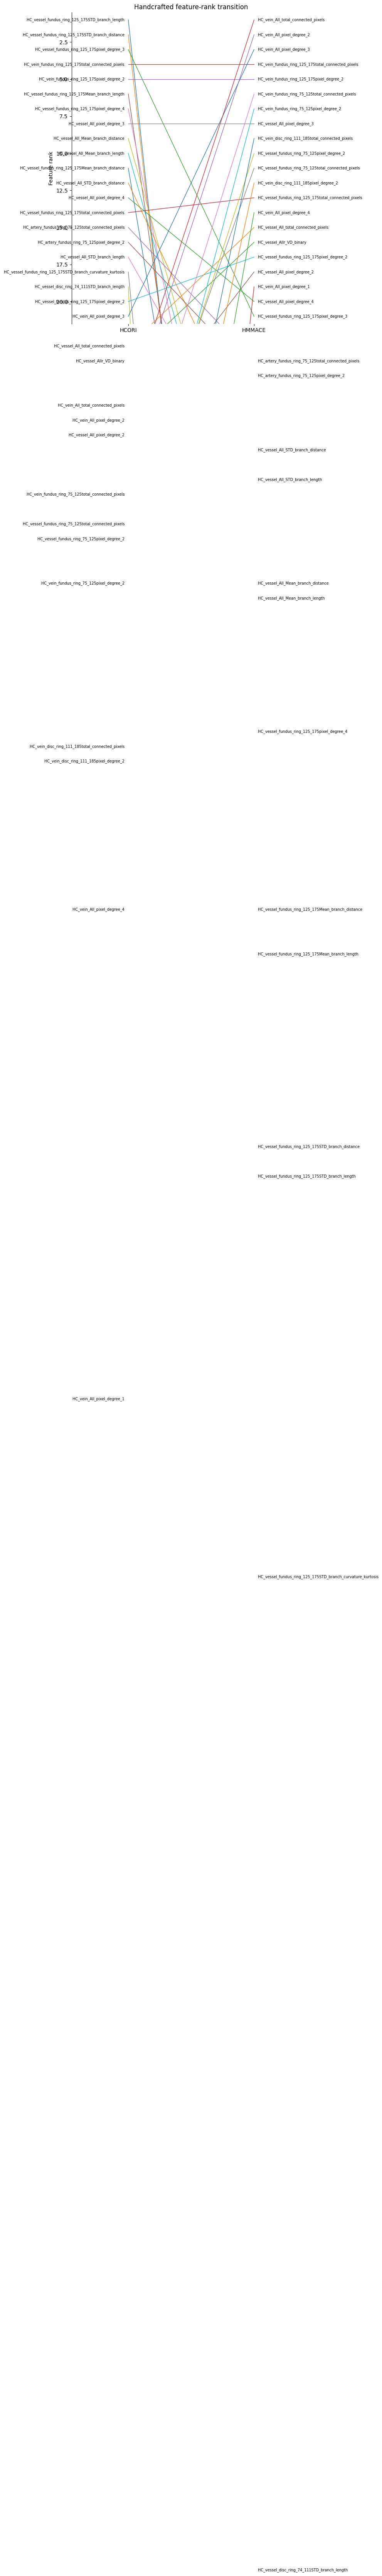

In [49]:
# ============================================================
# Complete handcrafted retinal-feature analysis
# ============================================================

from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

from src.metrics import handcrafted_replication_table


if RUN_HANDCRAFTED:

    # --------------------------------------------------------
    # 1. Load and validate the subject-level handcrafted table
    # --------------------------------------------------------

    if not HANDCRAFTED_FILE.exists():
        raise FileNotFoundError(
            f"Handcrafted feature file not found: {HANDCRAFTED_FILE}"
        )

    handcrafted_source = pd.read_csv(
        HANDCRAFTED_FILE,
        low_memory=False,
    )

    handcrafted_source.columns = (
        handcrafted_source.columns
        .astype(str)
        .str.strip()
    )

    if "eid" not in handcrafted_source.columns:
        raise KeyError(
            "The handcrafted feature table must contain an eid column."
        )

    handcrafted_source["eid"] = pd.to_numeric(
        handcrafted_source["eid"],
        errors="raise",
    ).astype("int64")

    if handcrafted_source["eid"].duplicated().any():
        duplicate_eids = (
            handcrafted_source.loc[
                handcrafted_source["eid"].duplicated(
                    keep=False
                ),
                ["eid"],
            ]
            .sort_values("eid")
            .reset_index(drop=True)
        )

        duplicate_path = (
            QC_DIR
            / "handcrafted_duplicate_eids.csv"
        )

        duplicate_eids.to_csv(
            duplicate_path,
            index=False,
        )

        raise ValueError(
            "The handcrafted table contains duplicate EIDs. "
            f"See {duplicate_path}"
        )

    HANDCRAFTED_FEATURES = [
        column
        for column in handcrafted_source.columns
        if column.startswith("HC_")
    ]

    if not HANDCRAFTED_FEATURES:
        raise ValueError(
            "No columns beginning with HC_ were found."
        )

    handcrafted_features = handcrafted_source[
        [
            "eid",
            *HANDCRAFTED_FEATURES,
        ]
    ].copy()

    handcrafted_features[
        HANDCRAFTED_FEATURES
    ] = handcrafted_features[
        HANDCRAFTED_FEATURES
    ].apply(
        pd.to_numeric,
        errors="coerce",
    )

    print(
        f"Loaded {len(handcrafted_features):,} participants "
        f"and {len(HANDCRAFTED_FEATURES):,} HC features."
    )


    # --------------------------------------------------------
    # 2. Match the handcrafted descriptors to locked D1-D4
    # --------------------------------------------------------

    handcrafted = {}
    coverage_rows = []
    handcrafted_eids = set(
        handcrafted_features["eid"]
    )

    for cohort in [
        "D1",
        "D2",
        "D3",
        "D4",
    ]:
        cohort_data = (
            meanpool[cohort]
            .copy()
            .reset_index(drop=True)
        )

        cohort_data["eid"] = pd.to_numeric(
            cohort_data["eid"],
            errors="raise",
        ).astype("int64")

        if cohort_data["eid"].duplicated().any():
            raise ValueError(
                f"{cohort} contains duplicate EIDs."
            )

        missing_eids = cohort_data.loc[
            ~cohort_data["eid"].isin(
                handcrafted_eids
            ),
            [
                column
                for column in [
                    "eid",
                    "Y_mace",
                    "center",
                ]
                if column in cohort_data.columns
            ],
        ].copy()

        missing_eids.to_csv(
            QC_DIR
            / f"{cohort}_missing_handcrafted_eids.csv",
            index=False,
        )

        matched = cohort_data.merge(
            handcrafted_features,
            on="eid",
            how="inner",
            validate="one_to_one",
            sort=False,
        )

        coverage_rows.append(
            {
                "cohort": cohort,
                "original_N": len(cohort_data),
                "original_events": int(
                    cohort_data["Y_mace"].sum()
                ),
                "handcrafted_N": len(matched),
                "handcrafted_events": int(
                    matched["Y_mace"].sum()
                ),
                "matched_percent": (
                    100
                    * len(matched)
                    / len(cohort_data)
                ),
                "missing_handcrafted_N": (
                    len(cohort_data)
                    - len(matched)
                ),
                "missing_handcrafted_events": int(
                    missing_eids["Y_mace"].sum()
                )
                if "Y_mace" in missing_eids.columns
                else np.nan,
            }
        )

        handcrafted[cohort] = matched

    handcrafted_coverage = pd.DataFrame(
        coverage_rows
    )

    display(
        handcrafted_coverage
    )

    save_table(
        handcrafted_coverage,
        "Table_14A_handcrafted_feature_coverage",
    )


    # --------------------------------------------------------
    # 3. Retain descriptors estimable in both development sets
    # --------------------------------------------------------

    HANDCRAFTED_MODEL_FEATURES = [
        feature
        for feature in HANDCRAFTED_FEATURES
        if (
            handcrafted["D1"][feature]
            .nunique(dropna=True)
            > 1
        )
        and (
            handcrafted["D3"][feature]
            .nunique(dropna=True)
            > 1
        )
    ]

    excluded_handcrafted_features = sorted(
        set(HANDCRAFTED_FEATURES)
        - set(HANDCRAFTED_MODEL_FEATURES)
    )

    pd.DataFrame(
        {
            "excluded_feature": excluded_handcrafted_features
        }
    ).to_csv(
        QC_DIR
        / "handcrafted_nonestimable_features.csv",
        index=False,
    )

    print(
        f"Using {len(HANDCRAFTED_MODEL_FEATURES):,} "
        "nonconstant HC features."
    )


    # --------------------------------------------------------
    # 4. Train the cancer and never-cancer handcrafted models
    # --------------------------------------------------------

    hcori_model = train_model(
        handcrafted["D1"],
        HANDCRAFTED_MODEL_FEATURES,
        "HCORI",
        5,
        0.10,
    )

    hmmace_model = train_model(
        handcrafted["D3"],
        HANDCRAFTED_MODEL_FEATURES,
        "HMMACE",
        5,
        0.10,
    )

    save_model(
        hcori_model,
        MODEL_DIR / "HCORI_locked.pkl",
    )

    save_model(
        hmmace_model,
        MODEL_DIR / "HMMACE_locked.pkl",
    )


    # --------------------------------------------------------
    # 5. Apply both handcrafted models without refitting
    # --------------------------------------------------------

    for cohort in handcrafted:
        handcrafted[cohort] = score_model(
            hcori_model,
            handcrafted[cohort],
        )

        handcrafted[cohort] = score_model(
            hmmace_model,
            handcrafted[cohort],
        )


    # --------------------------------------------------------
    # 6. Cross-domain model performance
    # --------------------------------------------------------

    performance_rows = []

    score_specifications = [
        (
            "HCORI",
            "Handcrafted",
            "HCORI_z",
        ),
        (
            "HMMACE",
            "Handcrafted",
            "HMMACE_z",
        ),
        (
            "CORI",
            "Meanpool",
            "CORI_z",
        ),
        (
            "MMACE equal complexity",
            "Meanpool",
            "MMACE_equal_z",
        ),
        (
            "MMACE practical",
            "Meanpool",
            "MMACE_full_z",
        ),
    ]

    for cohort in [
        "D1",
        "D2",
        "D3",
        "D4",
    ]:
        data = handcrafted[cohort]

        for (
            model_label,
            representation,
            score_column,
        ) in score_specifications:
            if score_column not in data.columns:
                continue

            performance_rows.append(
                {
                    "cohort": cohort,
                    "model": model_label,
                    "representation": representation,
                    "N": len(data),
                    "events": int(
                        data["Y_mace"].sum()
                    ),
                    "C_index": c_index(
                        data,
                        score_column,
                    ),
                }
            )

    handcrafted_performance = pd.DataFrame(
        performance_rows
    )

    display(
        handcrafted_performance
    )

    save_table(
        handcrafted_performance,
        "Table_14B_handcrafted_cross_domain",
    )


    # --------------------------------------------------------
    # 7. Handcrafted model feature-rank transition
    # --------------------------------------------------------

    rank_transition(
        hcori_model.ranking,
        hmmace_model.ranking,
        "HCORI",
        "HMMACE",
        20,
        "Handcrafted feature-rank transition",
        (
            FIGURE_DIR
            / "Figure_S_handcrafted_rank_transition"
        ),
    )


    # --------------------------------------------------------
    # 8. D1 discovery and locked D2 partial-correlation replication
    # --------------------------------------------------------

    HANDCRAFTED_ADJUSTMENT = PRIMARY_ADJUSTMENT

    (
        all_handcrafted_correlations,
        top_handcrafted_replication,
    ) = handcrafted_replication_table(
        development=handcrafted["D1"],
        heldout=handcrafted["D2"],
        score_column="CORI_z",
        feature_columns=HANDCRAFTED_MODEL_FEATURES,
        covariates=HANDCRAFTED_ADJUSTMENT,
        top_n=10,
    )


    # --------------------------------------------------------
    # 9. Add FDR-corrected raw D2 Spearman and supportive Pearson
    # --------------------------------------------------------

    raw_spearman_valid = (
        all_handcrafted_correlations[
            "heldout_raw_p"
        ]
        .notna()
    )

    all_handcrafted_correlations.loc[
        raw_spearman_valid,
        "heldout_raw_q",
    ] = multipletests(
        all_handcrafted_correlations.loc[
            raw_spearman_valid,
            "heldout_raw_p",
        ],
        method="fdr_bh",
    )[1]

    pearson_rows = []

    for feature in HANDCRAFTED_MODEL_FEATURES:
        pair = (
            handcrafted["D2"][
                [
                    "CORI_z",
                    feature,
                ]
            ]
            .apply(
                pd.to_numeric,
                errors="coerce",
            )
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
            .dropna()
        )

        if (
            len(pair) >= 30
            and pair["CORI_z"].nunique() > 1
            and pair[feature].nunique() > 1
        ):
            pearson_r, pearson_p = pearsonr(
                pair["CORI_z"],
                pair[feature],
            )
        else:
            pearson_r = np.nan
            pearson_p = np.nan

        pearson_rows.append(
            {
                "feature": feature,
                "heldout_raw_pearson_r": pearson_r,
                "heldout_raw_pearson_p": pearson_p,
            }
        )

    pearson_table = pd.DataFrame(
        pearson_rows
    )

    pearson_valid = (
        pearson_table[
            "heldout_raw_pearson_p"
        ]
        .notna()
    )

    pearson_table.loc[
        pearson_valid,
        "heldout_raw_pearson_q",
    ] = multipletests(
        pearson_table.loc[
            pearson_valid,
            "heldout_raw_pearson_p",
        ],
        method="fdr_bh",
    )[1]

    all_handcrafted_correlations = (
        all_handcrafted_correlations
        .merge(
            pearson_table,
            on="feature",
            how="left",
            validate="one_to_one",
        )
    )


    # --------------------------------------------------------
    # 10. Main manuscript-style top-10 raw D2 correlations
    # --------------------------------------------------------

    significant_raw = (
        all_handcrafted_correlations.loc[
            all_handcrafted_correlations[
                "heldout_raw_q"
            ].lt(0.05)
        ]
        .copy()
    )

    significant_raw[
        "abs_heldout_raw_rho"
    ] = significant_raw[
        "heldout_raw_rho"
    ].abs()

    top_raw_handcrafted = (
        significant_raw
        .sort_values(
            [
                "abs_heldout_raw_rho",
                "feature",
            ],
            ascending=[
                False,
                True,
            ],
        )
        .head(10)
        [
            [
                "feature",
                "heldout_N",
                "heldout_raw_rho",
                "heldout_raw_p",
                "heldout_raw_q",
                "heldout_raw_pearson_r",
                "heldout_raw_pearson_p",
                "heldout_raw_pearson_q",
                "heldout_partial_rho",
                "heldout_p",
                "heldout_q",
            ]
        ]
        .reset_index(drop=True)
    )

    display(
        top_raw_handcrafted
    )

    display(
        top_handcrafted_replication
    )

    save_table(
        all_handcrafted_correlations,
        "Table_14C_all_handcrafted_CORI_correlations",
    )

    save_table(
        top_handcrafted_replication,
        "Table_14D_D1_selected_D2_replicated_handcrafted_correlations",
    )

    save_table(
        top_raw_handcrafted,
        "Table_14E_top10_raw_D2_handcrafted_CORI_correlations",
    )

## 19. CMR biological anchoring in D6

In [50]:
import importlib
import inspect
import src.cmr as cmr_module

cmr_module = importlib.reload(cmr_module)

association_table = cmr_module.association_table
domain_acat = cmr_module.domain_acat
domain_pc_table = cmr_module.domain_pc_table
signed_domain_association_table = (
    cmr_module.signed_domain_association_table
)

print("Loaded CMR module from:", cmr_module.__file__)
print(inspect.signature(cmr_module.adjusted_association))

Loaded CMR module from: f:\CORI_Final\CORI_JACC_Final\CORI_Submit\code\src\cmr.py
(df: 'pd.DataFrame', outcome: 'str', score: 'str', covariates: 'list[str]') -> 'dict'


In [51]:
# ============================================================
# Complete CMR biological-association analysis
# Includes all helper definitions needed by this cell.
# ============================================================

from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

from src.data import collapse_cmr_columns, merge_columns
from src.cmr import (
    acat,
    association_table,
    domain_pc_table,
    signed_domain_association_table,
)


# ------------------------------------------------------------
# 1. Prespecified source-column mapping
# ------------------------------------------------------------

CMR_COLUMN_MAP = {
    "LV ejection fraction": (
        "LV ejection fraction | Instance 2",
        "LV ejection fraction | Instance 3",
    ),
    "LV end diastolic volume": (
        "LV end diastolic volume | Instance 2",
        "LV end diastolic volume | Instance 3",
    ),
    "LV end systolic volume": (
        "LV end systolic volume | Instance 2",
        "LV end systolic volume | Instance 3",
    ),
    "LV stroke volume": (
        "LV stroke volume | Instance 2",
        "LV stroke volume | Instance 3",
    ),
    "LV myocardial mass": (
        "LV myocardial mass | Instance 2",
        "LV myocardial mass | Instance 3",
    ),
    "Central systolic blood pressure during PWA - PVR": (
        "Central systolic blood pressure during PWA - PVR | Instance 2 | Array 0",
        "Central systolic blood pressure during PWA - PVR | Instance 3 | Array 0",
    ),
    "End systolic pressure during PWA - PVR": (
        "End systolic pressure during PWA - PVR | Instance 2 | Array 0",
        "End systolic pressure during PWA - PVR | Instance 3 | Array 0",
    ),
    "Central pulse pressure during PWA - PVR": (
        "Central pulse pressure during PWA - PVR | Instance 2 | Array 0",
        "Central pulse pressure during PWA - PVR | Instance 3 | Array 0",
    ),
    "Mean arterial pressure during PWA - PVR": (
        "Mean arterial pressure during PWA - PVR | Instance 2 | Array 0",
        "Mean arterial pressure during PWA - PVR | Instance 3 | Array 0",
    ),
    "Cardiac output during PWA - PVR": (
        "Cardiac output during PWA - PVR | Instance 2 | Array 0",
        "Cardiac output during PWA - PVR | Instance 3 | Array 0",
    ),
    "Ascending aorta maximum area": (
        "Ascending aorta maximum area | Instance 2",
        "Ascending aorta maximum area | Instance 3",
    ),
    "Ascending aorta minimum area": (
        "Ascending aorta minimum area | Instance 2",
        "Ascending aorta minimum area | Instance 3",
    ),
    "Ascending aorta distensibility": (
        "Ascending aorta distensibility | Instance 2",
        "Ascending aorta distensibility | Instance 3",
    ),
    "Descending aorta maximum area": (
        "Descending aorta maximum area | Instance 2",
        "Descending aorta maximum area | Instance 3",
    ),
    "Descending aorta minimum area": (
        "Descending aorta minimum area | Instance 2",
        "Descending aorta minimum area | Instance 3",
    ),
    "Descending aorta distensibility": (
        "Descending aorta distensibility | Instance 2",
        "Descending aorta distensibility | Instance 3",
    ),
}


CMR_DOMAINS = {
    "LV remodeling": [
        "LV ejection fraction",
        "LV end diastolic volume",
        "LV end systolic volume",
        "LV stroke volume",
        "LV myocardial mass",
    ],
    "Central pressure / PWA": [
        "Central systolic blood pressure during PWA - PVR",
        "End systolic pressure during PWA - PVR",
        "Central pulse pressure during PWA - PVR",
        "Mean arterial pressure during PWA - PVR",
        "Cardiac output during PWA - PVR",
    ],
    "Aortic remodeling": [
        "Ascending aorta maximum area",
        "Ascending aorta minimum area",
        "Ascending aorta distensibility",
        "Descending aorta maximum area",
        "Descending aorta minimum area",
        "Descending aorta distensibility",
    ],
}


CMR_PHENOTYPES = [
    phenotype
    for phenotypes in CMR_DOMAINS.values()
    for phenotype in phenotypes
]


# Clinically fixed adverse-remodeling directions.
# +1 means a higher phenotype is considered adverse-aligned.
# -1 means a lower phenotype is considered adverse-aligned.
CMR_DIRECTION = {
    "LV ejection fraction": -1,
    "LV end diastolic volume": +1,
    "LV end systolic volume": +1,
    "LV stroke volume": -1,
    "LV myocardial mass": +1,

    "Central systolic blood pressure during PWA - PVR": +1,
    "End systolic pressure during PWA - PVR": +1,
    "Central pulse pressure during PWA - PVR": +1,
    "Mean arterial pressure during PWA - PVR": +1,
    "Cardiac output during PWA - PVR": -1,

    "Ascending aorta maximum area": +1,
    "Ascending aorta minimum area": +1,
    "Ascending aorta distensibility": -1,
    "Descending aorta maximum area": +1,
    "Descending aorta minimum area": +1,
    "Descending aorta distensibility": -1,
}


CMR_SIGNED_DOMAINS = {
    "LV adverse remodeling composite": {
        "LV ejection fraction": -1,
        "LV end diastolic volume": +1,
        "LV end systolic volume": +1,
        "LV stroke volume": -1,
        "LV myocardial mass": +1,
    },
    "Central hemodynamic load composite": {
        "Central systolic blood pressure during PWA - PVR": +1,
        "End systolic pressure during PWA - PVR": +1,
        "Central pulse pressure during PWA - PVR": +1,
        "Mean arterial pressure during PWA - PVR": +1,
        "Cardiac output during PWA - PVR": -1,
    },
    "Aortic adverse remodeling composite": {
        "Ascending aorta maximum area": +1,
        "Ascending aorta minimum area": +1,
        "Ascending aorta distensibility": -1,
        "Descending aorta maximum area": +1,
        "Descending aorta minimum area": +1,
        "Descending aorta distensibility": -1,
    },
}


# ------------------------------------------------------------
# 2. Local helper functions
# These prevent the add_directional_p_values NameError.
# ------------------------------------------------------------

def add_directional_p_values(
    table,
    directions,
):
    """
    Convert robust two-sided standardized-beta results into
    clinically prespecified one-sided directional p-values.
    """
    output = table.copy()

    output["direction"] = (
        output["phenotype"]
        .map(directions)
    )

    output["standard_error"] = (
        output["CI_high"]
        - output["CI_low"]
    ) / (
        2 * norm.ppf(0.975)
    )

    valid = (
        output["direction"].notna()
        & output["beta"].notna()
        & output["standard_error"].notna()
        & output["standard_error"].gt(0)
    )

    output["directional_z"] = np.nan
    output["directional_p"] = np.nan

    output.loc[
        valid,
        "directional_z",
    ] = (
        output.loc[
            valid,
            "direction",
        ]
        * output.loc[
            valid,
            "beta",
        ]
        / output.loc[
            valid,
            "standard_error",
        ]
    )

    output.loc[
        valid,
        "directional_p",
    ] = norm.sf(
        output.loc[
            valid,
            "directional_z",
        ]
    )

    valid_directional = (
        output["directional_p"]
        .notna()
    )

    if valid_directional.any():
        output.loc[
            valid_directional,
            "directional_q_all_phenotypes",
        ] = multipletests(
            output.loc[
                valid_directional,
                "directional_p",
            ],
            method="fdr_bh",
        )[1]

    return output


def domain_acat_from_column(
    table,
    domains,
    p_column,
):
    """
    Combine the specified component p-value column within each domain.
    """
    rows = []

    for domain, phenotypes in domains.items():
        subset = table.loc[
            table["phenotype"].isin(
                phenotypes
            )
        ].copy()

        p_values = pd.to_numeric(
            subset[p_column],
            errors="coerce",
        )

        rows.append(
            {
                "domain": domain,
                "p_column": p_column,
                "n_phenotypes": int(
                    p_values.notna().sum()
                ),
                "ACAT_p": acat(
                    p_values
                ),
            }
        )

    result = pd.DataFrame(
        rows
    )

    valid = result["ACAT_p"].notna()

    if valid.any():
        result.loc[
            valid,
            "q",
        ] = multipletests(
            result.loc[
                valid,
                "ACAT_p",
            ],
            method="fdr_bh",
        )[1]

    return result


# ------------------------------------------------------------
# 3. Read, validate, collapse, and merge the CMR data
# ------------------------------------------------------------

if RUN_CMR:

    if not CMR_FILE.exists():
        raise FileNotFoundError(
            f"CMR CSV not found: {CMR_FILE}"
        )

    cmr_raw = pd.read_csv(
        CMR_FILE,
        low_memory=False,
    )

    cmr_raw.columns = (
        cmr_raw.columns
        .astype(str)
        .str.strip()
    )

    if "eid" not in cmr_raw.columns:
        raise KeyError(
            "cardiac_mri.csv does not contain an eid column."
        )

    cmr_raw["eid"] = pd.to_numeric(
        cmr_raw["eid"],
        errors="raise",
    ).astype("int64")

    source_columns = [
        source_column
        for instance_columns in CMR_COLUMN_MAP.values()
        for source_column in instance_columns
    ]

    missing_source_columns = [
        column
        for column in source_columns
        if column not in cmr_raw.columns
    ]

    if missing_source_columns:
        raise KeyError(
            "The following prespecified CMR source columns are missing:\n"
            + "\n".join(
                missing_source_columns
            )
        )

    cmr_subject = collapse_cmr_columns(
        cmr_raw,
        CMR_COLUMN_MAP,
    )

    cmr_subject["eid"] = pd.to_numeric(
        cmr_subject["eid"],
        errors="raise",
    ).astype("int64")

    if cmr_subject["eid"].duplicated().any():
        raise ValueError(
            "The collapsed CMR table contains duplicate EIDs."
        )

    expected_cmr_columns = [
        "eid",
        *CMR_PHENOTYPES,
    ]

    missing_collapsed_columns = [
        column
        for column in expected_cmr_columns
        if column not in cmr_subject.columns
    ]

    if missing_collapsed_columns:
        raise KeyError(
            "collapse_cmr_columns() did not create:\n"
            + "\n".join(
                missing_collapsed_columns
            )
        )

    cmr_subject = cmr_subject[
        expected_cmr_columns
    ].copy()

    d6_base = (
        meanpool["D6"]
        .copy()
        .reset_index(drop=True)
    )

    d6_base["eid"] = pd.to_numeric(
        d6_base["eid"],
        errors="raise",
    ).astype("int64")

    previously_attached_cmr_columns = [
        column
        for column in CMR_PHENOTYPES
        if column in d6_base.columns
    ]

    if previously_attached_cmr_columns:
        d6_base = d6_base.drop(
            columns=previously_attached_cmr_columns
        )

    d6 = merge_columns(
        d6_base,
        cmr_subject.reset_index(drop=True),
    )

    missing_after_merge = [
        column
        for column in CMR_PHENOTYPES
        if column not in d6.columns
    ]

    if missing_after_merge:
        raise KeyError(
            "CMR phenotypes missing after merge:\n"
            + "\n".join(
                missing_after_merge
            )
        )


    # --------------------------------------------------------
    # 4. Coverage audit
    # --------------------------------------------------------

    d6["has_any_cmr_phenotype"] = (
        d6[CMR_PHENOTYPES]
        .notna()
        .any(axis=1)
    )

    d6["has_all_cmr_phenotypes"] = (
        d6[CMR_PHENOTYPES]
        .notna()
        .all(axis=1)
    )

    phenotype_coverage = pd.DataFrame(
        [
            {
                "phenotype": phenotype,
                "nonmissing_N": int(
                    d6[phenotype]
                    .notna()
                    .sum()
                ),
                "missing_N": int(
                    d6[phenotype]
                    .isna()
                    .sum()
                ),
                "nonmissing_percent": float(
                    100
                    * d6[phenotype]
                    .notna()
                    .mean()
                ),
            }
            for phenotype in CMR_PHENOTYPES
        ]
    )

    cmr_coverage = pd.DataFrame(
        [
            {
                "D6_N": len(d6),
                "D6_events": int(
                    d6["Y_mace"].sum()
                ),
                "participants_with_any_CMR": int(
                    d6[
                        "has_any_cmr_phenotype"
                    ].sum()
                ),
                "participants_with_all_CMR": int(
                    d6[
                        "has_all_cmr_phenotypes"
                    ].sum()
                ),
            }
        ]
    )

    display(
        cmr_coverage
    )

    display(
        phenotype_coverage
    )

    save_table(
        cmr_coverage,
        "Table_15A_CMR_participant_coverage",
    )

    save_table(
        phenotype_coverage,
        "Table_15B_CMR_phenotype_coverage",
    )


    # --------------------------------------------------------
    # 5. Primary manuscript-aligned component analysis
    # age, sex, height, diabetes, and hypertension
    # --------------------------------------------------------

    CMR_PRIMARY_COVARIATES = PRIMARY_ADJUSTMENT

    cmr_associations_primary = association_table(
        d6,
        CMR_PHENOTYPES,
        "CORI_z",
        CMR_PRIMARY_COVARIATES,
    )

    cmr_directional = add_directional_p_values(
        cmr_associations_primary,
        CMR_DIRECTION,
    )

    cmr_domains_directional = (
        domain_acat_from_column(
            cmr_directional,
            CMR_DOMAINS,
            p_column="directional_p",
        )
    )

    global_directional_p = acat(
        cmr_directional[
            "directional_p"
        ]
    )

    cmr_domains_directional[
        "global_directional_ACAT_p"
    ] = global_directional_p


    # --------------------------------------------------------
    # 6. Two-sided sensitivity using the same primary adjustment set
    # --------------------------------------------------------

    CMR_SENSITIVITY_COVARIATES = PRIMARY_ADJUSTMENT

    cmr_associations_two_sided = (
        association_table(
            d6,
            CMR_PHENOTYPES,
            "CORI_z",
            CMR_SENSITIVITY_COVARIATES,
        )
    )

    cmr_domains_two_sided = (
        domain_acat_from_column(
            cmr_associations_two_sided,
            CMR_DOMAINS,
            p_column="p",
        )
    )


    # --------------------------------------------------------
    # 7. Global-first residualized domain-PC sensitivity
    # --------------------------------------------------------

    cmr_pc, cmr_global_fisher_p = (
        domain_pc_table(
            d6,
            CMR_DOMAINS,
            "CORI_z",
            CMR_SENSITIVITY_COVARIATES,
        )
    )

    cmr_pc[
        "global_Fisher_p"
    ] = cmr_global_fisher_p


    # --------------------------------------------------------
    # 8. Exploratory biologically signed domain composites
    # --------------------------------------------------------

    (
        signed_cmr_associations,
        d6_signed,
    ) = signed_domain_association_table(
        d6,
        signed_domains=CMR_SIGNED_DOMAINS,
        score="CORI_z",
        covariates=CMR_PRIMARY_COVARIATES,
        require_complete=True,
    )


    # --------------------------------------------------------
    # 9. Save and display every analysis
    # --------------------------------------------------------

    display(
        cmr_associations_primary
    )

    display(
        cmr_directional
    )

    display(
        cmr_domains_directional
    )

    display(
        cmr_associations_two_sided
    )

    display(
        cmr_pc
    )

    display(
        signed_cmr_associations
    )

    save_table(
        cmr_associations_primary,
        "Table_15C_primary_CMR_associations",
    )

    save_table(
        cmr_directional,
        "Table_15D_CMR_directional_component_tests",
    )

    save_table(
        cmr_domains_directional,
        "Table_15E_CMR_directional_domain_ACAT",
    )

    save_table(
        cmr_associations_two_sided,
        "Table_15F_CMR_two_sided_sensitivity",
    )

    save_table(
        cmr_domains_two_sided,
        "Table_15G_CMR_domain_ACAT_sensitivity",
    )

    save_table(
        cmr_pc,
        "Table_15H_CMR_domain_PC_global_first_sensitivity",
    )

    save_table(
        signed_cmr_associations,
        "Table_15I_signed_CMR_domain_composites_exploratory",
    )

,D6_N,D6_events,participants_with_any_CMR,participants_with_all_CMR
0,611,56,562,248


,phenotype,nonmissing_N,missing_N,nonmissing_percent
0,LV ejection fraction,307,304,50.245499
1,LV end diastolic volume,307,304,50.245499
2,LV end systolic volume,307,304,50.245499
3,LV stroke volume,307,304,50.245499
4,LV myocardial mass,305,306,49.918167
5,Central systolic blood pressure during PWA - PVR,534,77,87.397709
6,End systolic pressure during PWA - PVR,534,77,87.397709
7,Central pulse pressure during PWA - PVR,534,77,87.397709
8,Mean arterial pressure during PWA - PVR,534,77,87.397709
9,Cardiac output during PWA - PVR,505,106,82.651391


F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_15A_CMR_participant_coverage.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_15B_CMR_phenotype_coverage.csv


,phenotype,N,beta,CI_low,CI_high,p,q
0,LV ejection fraction,307,-0.082460,-0.229904,0.064985,0.273023,0.485375
1,LV end diastolic volume,307,0.151674,0.043605,0.259742,0.005945,0.079113
2,LV end systolic volume,307,0.144974,0.034827,0.255120,0.009889,0.079113
3,LV stroke volume,307,0.124644,0.000806,0.248481,0.048527,0.161996
4,LV myocardial mass,305,-0.000429,-0.111632,0.110774,0.993966,0.993966
5,Central systolic blood pressure during PWA - PVR,534,0.024705,-0.071834,0.121244,0.615975,0.758123
6,End systolic pressure during PWA - PVR,534,0.104031,0.006003,0.202059,0.037526,0.161996
7,Central pulse pressure during PWA - PVR,534,-0.041915,-0.138386,0.054556,0.394454,0.573751
8,Mean arterial pressure during PWA - PVR,534,0.100285,-0.000272,0.200842,0.050624,0.161996
9,Cardiac output during PWA - PVR,505,-0.012520,-0.111796,0.086755,0.804763,0.919729


,phenotype,N,beta,CI_low,CI_high,p,q,direction,standard_error,directional_z,directional_p,directional_q_all_phenotypes
0,LV ejection fraction,307,-0.082460,-0.229904,0.064985,0.273023,0.485375,-1,0.075228,1.096127,0.136512,0.273023
1,LV end diastolic volume,307,0.151674,0.043605,0.259742,0.005945,0.079113,1,0.055138,2.750807,0.002972,0.039556
2,LV end systolic volume,307,0.144974,0.034827,0.255120,0.009889,0.079113,1,0.056198,2.579683,0.004945,0.039556
3,LV stroke volume,307,0.124644,0.000806,0.248481,0.048527,0.161996,-1,0.063184,-1.972721,0.975736,0.975736
4,LV myocardial mass,305,-0.000429,-0.111632,0.110774,0.993966,0.993966,1,0.056737,-0.007562,0.503017,0.619098
5,Central systolic blood pressure during PWA - PVR,534,0.024705,-0.071834,0.121244,0.615975,0.758123,1,0.049256,0.501563,0.307988,0.492780
6,End systolic pressure during PWA - PVR,534,0.104031,0.006003,0.202059,0.037526,0.161996,1,0.050015,2.079996,0.018763,0.100069
7,Central pulse pressure during PWA - PVR,534,-0.041915,-0.138386,0.054556,0.394454,0.573751,1,0.049221,-0.851569,0.802773,0.878976
8,Mean arterial pressure during PWA - PVR,534,0.100285,-0.000272,0.200842,0.050624,0.161996,1,0.051306,1.954655,0.025312,0.101248
9,Cardiac output during PWA - PVR,505,-0.012520,-0.111796,0.086755,0.804763,0.919729,-1,0.050652,0.247188,0.402381,0.585282


,domain,p_column,n_phenotypes,ACAT_p,q,global_directional_ACAT_p
0,LV remodeling,directional_p,5,0.009911,0.029732,0.025267
1,Central pressure / PWA,directional_p,5,0.054168,0.081251,0.025267
2,Aortic remodeling,directional_p,6,0.153015,0.153015,0.025267


,phenotype,N,beta,CI_low,CI_high,p,q
0,LV ejection fraction,307,-0.082460,-0.229904,0.064985,0.273023,0.485375
1,LV end diastolic volume,307,0.151674,0.043605,0.259742,0.005945,0.079113
2,LV end systolic volume,307,0.144974,0.034827,0.255120,0.009889,0.079113
3,LV stroke volume,307,0.124644,0.000806,0.248481,0.048527,0.161996
4,LV myocardial mass,305,-0.000429,-0.111632,0.110774,0.993966,0.993966
5,Central systolic blood pressure during PWA - PVR,534,0.024705,-0.071834,0.121244,0.615975,0.758123
6,End systolic pressure during PWA - PVR,534,0.104031,0.006003,0.202059,0.037526,0.161996
7,Central pulse pressure during PWA - PVR,534,-0.041915,-0.138386,0.054556,0.394454,0.573751
8,Mean arterial pressure during PWA - PVR,534,0.100285,-0.000272,0.200842,0.050624,0.161996
9,Cardiac output during PWA - PVR,505,-0.012520,-0.111796,0.086755,0.804763,0.919729


,domain,N,rho,p,q,global_Fisher_p
0,LV remodeling,300,0.092073,0.111502,0.219164,0.141357
1,Central pressure / PWA,505,0.030161,0.498870,0.498870,0.141357
2,Aortic remodeling,258,0.090739,0.146109,0.219164,0.141357


,phenotype,N,beta,CI_low,CI_high,p,missing_components,n_components,q
0,LV adverse remodeling composite,300,0.088961,-0.022962,0.200884,0.119265,,5,0.253971
1,Central hemodynamic load composite,505,0.060887,-0.039787,0.161562,0.235871,,5,0.253971
2,Aortic adverse remodeling composite,258,0.080678,-0.057937,0.219293,0.253971,,6,0.253971


F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_15C_primary_CMR_associations.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_15D_CMR_directional_component_tests.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_15E_CMR_directional_domain_ACAT.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_15F_CMR_two_sided_sensitivity.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_15G_CMR_domain_ACAT_sensitivity.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_15H_CMR_domain_PC_global_first_sensitivity.csv
F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables\Table_15I_signed_CMR_domain_composites_exploratory.csv


## 20. Export held-out and cross-fitted scores for survival mediation

In [52]:
# Primary held-out mediation input.
mediation_heldout = pd.concat(
    [
        meanpool["D2"].assign(
            A_cancer=1,
            mediation_cohort="D2 cancer held-out",
        ),
        meanpool["D4"].assign(
            A_cancer=0,
            mediation_cohort="D4 never-cancer held-out",
        ),
    ],
    ignore_index=True,
)

mediation_columns = [
    "eid", "A_cancer", "Y_mace", "time_years",
    "age", "female", "height", "center", "Diabetes", "HTN",
    "CORI_z", "MMACE_equal_z", "MMACE_tuned_z", "MMACE_full_z",
    "MMACE_matched_ensemble_z", "mediation_cohort",
]
mediation_heldout[mediation_columns].to_csv(
    SCORE_DIR / "mediation_heldout_D2_D4.csv",
    index=False,
)

# Higher-power sensitivity: every development participant receives an
# out-of-fold score; held-out participants receive locked scores.
if RUN_CROSSFIT_MEDIATION:
    d1_cf = meanpool["D1"].copy()
    d2_cf = meanpool["D2"].copy()
    d3_cf = meanpool["D3"].copy()
    d4_cf = meanpool["D4"].copy()

    d1_cf["CORI_cf_z"] = out_of_fold_score(
        d1_cf,
        DEEP_FEATURES,
        name="CORI_crossfit",
        n_features=CORI_K,
        penalizer=CORI_PENALIZER,
        folds=5,
        seed=SEED,
    )
    d2_cf["CORI_cf_z"] = score_values(cori_model, d2_cf)
    d3_cf["CORI_cf_z"] = score_values(cori_model, d3_cf)
    d4_cf["CORI_cf_z"] = score_values(cori_model, d4_cf)

    d3_cf["MMACE_equal_cf_z"] = out_of_fold_score(
        d3_cf,
        DEEP_FEATURES,
        name="MMACE_equal_crossfit",
        n_features=CORI_K,
        penalizer=CORI_PENALIZER,
        folds=5,
        seed=SEED,
    )
    d1_cf["MMACE_equal_cf_z"] = score_values(mmace_equal_model, d1_cf)
    d2_cf["MMACE_equal_cf_z"] = score_values(mmace_equal_model, d2_cf)
    d4_cf["MMACE_equal_cf_z"] = score_values(mmace_equal_model, d4_cf)

    mediation_crossfitted = pd.concat(
        [
            d1_cf.assign(A_cancer=1, mediation_cohort="D1 cancer cross-fitted"),
            d2_cf.assign(A_cancer=1, mediation_cohort="D2 cancer held-out"),
            d3_cf.assign(A_cancer=0, mediation_cohort="D3 never-cancer cross-fitted"),
            d4_cf.assign(A_cancer=0, mediation_cohort="D4 never-cancer held-out"),
        ],
        ignore_index=True,
    )

    crossfit_columns = [
        "eid", "A_cancer", "Y_mace", "time_years",
        "age", "female", "height", "center", "Diabetes", "HTN",
        "CORI_cf_z", "MMACE_equal_cf_z", "mediation_cohort",
    ]
    mediation_crossfitted[crossfit_columns].to_csv(
        SCORE_DIR / "mediation_crossfitted_D1_D4.csv",
        index=False,
    )

all_scores = []
for cohort in ["D1", "D2", "D3", "D4", "D6"]:
    columns = [
        "eid", "Y_mace", "time_years", "A_cancer",
        "age", "female", "height", "center",
        "CORI_z", "CORI_tuned_z",
        "MMACE_equal_z", "MMACE_tuned_z", "MMACE_full_z",
        "MMACE_matched_ensemble_z",
    ]
    available = [
        column for column in columns
        if column in meanpool[cohort]
    ]
    table = meanpool[cohort][available].copy()
    table["cohort"] = cohort
    all_scores.append(table)

pd.concat(all_scores, ignore_index=True).to_csv(
    SCORE_DIR / "locked_scores_all_cohorts.csv",
    index=False,
)

## 21. Final manifest

In [53]:
manifest = {
    "seed": SEED,
    "discrimination_representation": "meanpool_pre",
    "specificity_representation": "cls",
    "CORI_locked": {
        "development": "D1",
        "heldout": "D2",
        "k": CORI_K,
        "penalizer": CORI_PENALIZER,
        "selected_features": cori_model.feature_columns,
    },
    "CORI_tuned_sensitivity": {
        "development": "D1",
        **cori_tuning_choice,
        "selected_features": cori_tuned_model.feature_columns,
    },
    "MMACE_equal_complexity": {
        "development": "D3",
        "k": CORI_K,
        "penalizer": CORI_PENALIZER,
        "selected_features": mmace_equal_model.feature_columns,
    },
    "MMACE_tuned": {
        "development": "D3",
        **mmace_tuning_choice,
        "selected_features": mmace_tuned_model.feature_columns,
    },
    "MMACE_practical": {
        "development": "D3",
        "heldout": "D4",
        "k": MMACE_PRACTICAL_K,
        "penalizer": MMACE_PRACTICAL_PENALIZER,
        "selected_features": mmace_full_model.feature_columns,
    },
    "MMACE_event_matched": {
        "target": "D1",
        "source": "D3",
        "k": CORI_K,
        "penalizer": CORI_PENALIZER,
        "match_variables": MATCH_VARIABLES,
        "repetitions": MATCHED_REPETITIONS,
        "primary_estimand": "distribution of individual matched-model C-indices",
        "ensemble_role": "sensitivity only",
    },
    "treatment_file_columns_used": ["eid", *TREATMENT_COLUMNS],
    "old_scores_loaded": False,
    "crossfitted_mediation_export": RUN_CROSSFIT_MEDIATION,
}
with (QC_DIR / "analysis_manifest.json").open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(manifest, handle, indent=2)

print("Analysis complete")
print("Tables:", TABLE_DIR)
print("Figures:", FIGURE_DIR)
print("Models:", MODEL_DIR)
print("Held-out mediation input:", SCORE_DIR / "mediation_heldout_D2_D4.csv")
if RUN_CROSSFIT_MEDIATION:
    print(
        "Cross-fitted mediation sensitivity:",
        SCORE_DIR / "mediation_crossfitted_D1_D4.csv",
    )

Analysis complete
Tables: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\tables
Figures: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\figures
Models: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\models
Held-out mediation input: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\scores\mediation_heldout_D2_D4.csv
Cross-fitted mediation sensitivity: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\scores\mediation_crossfitted_D1_D4.csv
